<a href="https://colab.research.google.com/github/rvs0514/quant3/blob/main/strategy_logic_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ Strategy Logic Implementation
### Moving Average Crossover · Mean Reversion · Volatility Breakout
### Signal Design · Parameter Sensitivity · How Small Choices Distort Results

---

## 📖 What This Notebook Is About

This notebook is **not** about finding alpha. The strategies here are deliberately simple and widely known.

The point is something more important: learning to **translate a market hypothesis into working code** with complete clarity about every assumption you are making — and then understanding how small, seemingly innocent modelling choices can dramatically inflate or deflate your results.

By the end you will understand:
- How to design signals cleanly from a stated hypothesis
- Why **look-ahead bias** is so easy to introduce and so hard to spot
- Why **parameter sensitivity** matters more than the best parameter
- How **transaction costs, signal smoothing, position sizing** each bend your results
- How to tell the difference between a genuine edge and an artefact of implementation

---

## 🗺️ Structure

| Module | Topic |
|--------|-------|
| 1 | Data & helper functions |
| 2 | Moving Average Crossover — signal design & variants |
| 3 | Mean Reversion — z-score signals & threshold effects |
| 4 | Volatility Breakout — ATR channels & regime conditioning |
| 5 | Parameter Sensitivity — heatmaps, stability surfaces |
| 6 | The Distortion Catalogue — 8 ways implementation choices bend results |
| 7 | Final comparison dashboard |

## 🔧 Module 0 — Setup

In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from itertools import product
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

# ── Core performance metrics ──────────────────────────────────────────────────
def sharpe(r, periods=252):
    r = pd.Series(r).dropna()
    return (r.mean() / r.std() * np.sqrt(periods)) if r.std() > 0 else 0

def max_drawdown(r):
    r = pd.Series(r).dropna()
    c = (1 + r).cumprod()
    return ((c - c.cummax()) / c.cummax()).min()

def ann_return(r, periods=252):
    return pd.Series(r).dropna().mean() * periods

def ann_vol(r, periods=252):
    return pd.Series(r).dropna().std() * np.sqrt(periods)

def hit_rate(r):
    r = pd.Series(r).dropna()
    return (r > 0).mean()

def summary_stats(r, label='Strategy'):
    r = pd.Series(r).dropna()
    return pd.Series({
        'Label':         label,
        'Ann. Return':   f'{ann_return(r):.1%}',
        'Ann. Vol':      f'{ann_vol(r):.1%}',
        'Sharpe':        f'{sharpe(r):.2f}',
        'Max Drawdown':  f'{max_drawdown(r):.1%}',
        'Hit Rate':      f'{hit_rate(r):.1%}',
    })

def plot_strategy(returns_dict, title=''):
    """Plot cumulative returns for multiple strategies on one chart."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'mediumpurple']
    for (label, r), color in zip(returns_dict.items(), colors):
        r = pd.Series(r).dropna()
        cum = (1 + r).cumprod()
        axes[0].plot(cum, label=f'{label}  (SR={sharpe(r):.2f})', color=color, lw=1.8)
        _, dd = (cum - cum.cummax()) / cum.cummax(), None
        dd_s = (cum - cum.cummax()) / cum.cummax()
        axes[1].fill_between(dd_s.index, dd_s, 0, alpha=0.35, color=color)
    axes[0].set_title(title, fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Growth of $1')
    axes[0].legend(fontsize=9)
    axes[1].set_title('Drawdown', fontweight='bold')
    axes[1].set_ylabel('Drawdown')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.tight_layout()
    plt.show()

print('✅ Setup complete!')

✅ Setup complete!


---
## 📥 Module 1 — Data

We use **SPY** (S&P 500 ETF) as our primary instrument.  
A long, liquid, well-studied asset is ideal for strategy development — no liquidity assumptions, clean data, known behaviour.

✅ SPY: 3772 trading days  (2010-01-05 → 2024-12-30)
   Price range: $77 – $599
   Mean daily return: 0.0568%
   Daily volatility:  1.0742%


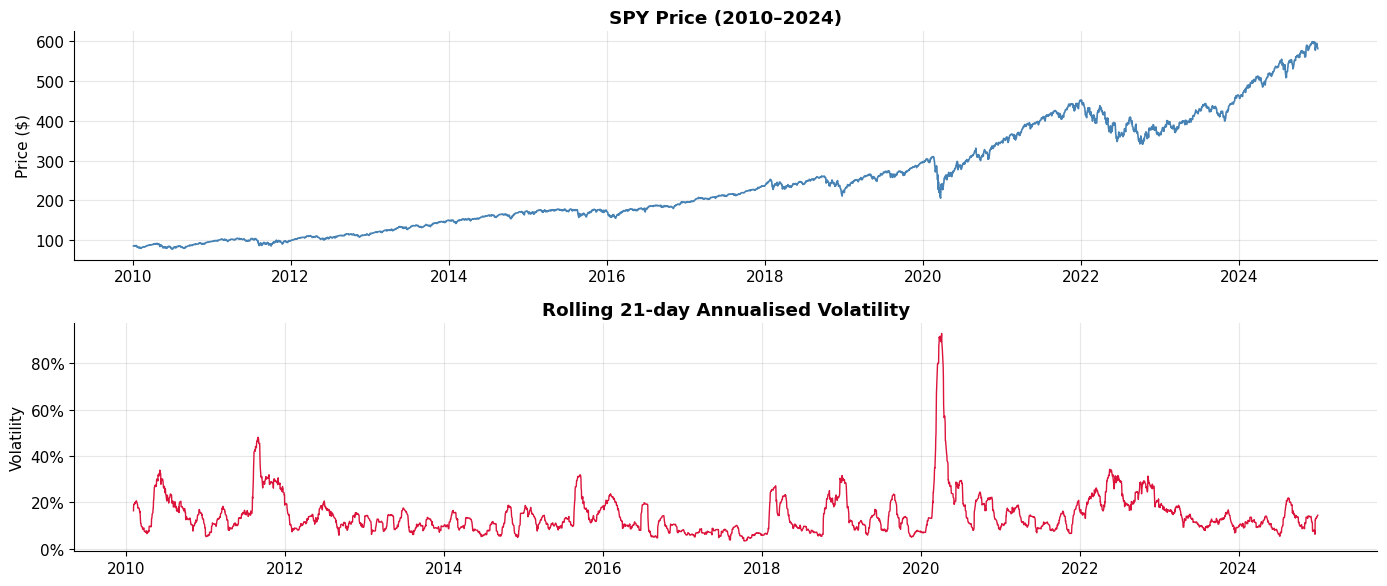

In [2]:
START  = '2010-01-01'
END    = '2024-12-31'
TICKER = 'SPY'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

price  = raw['Close'].squeeze()
high   = raw['High'].squeeze()
low    = raw['Low'].squeeze()
volume = raw['Volume'].squeeze()

returns = price.pct_change().dropna()
price   = price.reindex(returns.index)
high    = high.reindex(returns.index)
low     = low.reindex(returns.index)

print(f'✅ {TICKER}: {len(price)} trading days  ({price.index[0].date()} → {price.index[-1].date()})')
print(f'   Price range: ${price.min():.0f} – ${price.max():.0f}')
print(f'   Mean daily return: {returns.mean():.4%}')
print(f'   Daily volatility:  {returns.std():.4%}')

# Quick overview chart
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(price, color='steelblue', lw=1.2)
axes[0].set_title(f'{TICKER} Price ({START[:4]}–{END[:4]})', fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[1].plot(returns.rolling(21).std() * np.sqrt(252), color='crimson', lw=1)
axes[1].set_title('Rolling 21-day Annualised Volatility', fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

---
## 📈 Module 2 — Moving Average Crossover

### 2.0 — The Hypothesis

> *When a fast moving average crosses above a slow moving average, the trend has turned upward and we should be long. When it crosses below, the trend has turned downward and we should be flat (or short).*

This is a **trend-following** hypothesis. The assumption is that price momentum is persistent — a rising trend tends to keep rising.

Before writing a single line of code, we must state our assumptions explicitly:

```
ASSUMPTION 1: We trade at the CLOSE of the day the signal is generated
              (Relaxed: we trade at the OPEN of the NEXT day — more realistic)
ASSUMPTION 2: No transaction costs
ASSUMPTION 3: Positions are fully invested (1x long) or fully flat (0x)
ASSUMPTION 4: No slippage
ASSUMPTION 5: Signal is computed on adjusted close prices
```

Documenting assumptions is not bureaucracy — it is the entire game.  
Every violation of an assumption is a potential source of real-world underperformance.

### 2.1 — Clean Signal Implementation

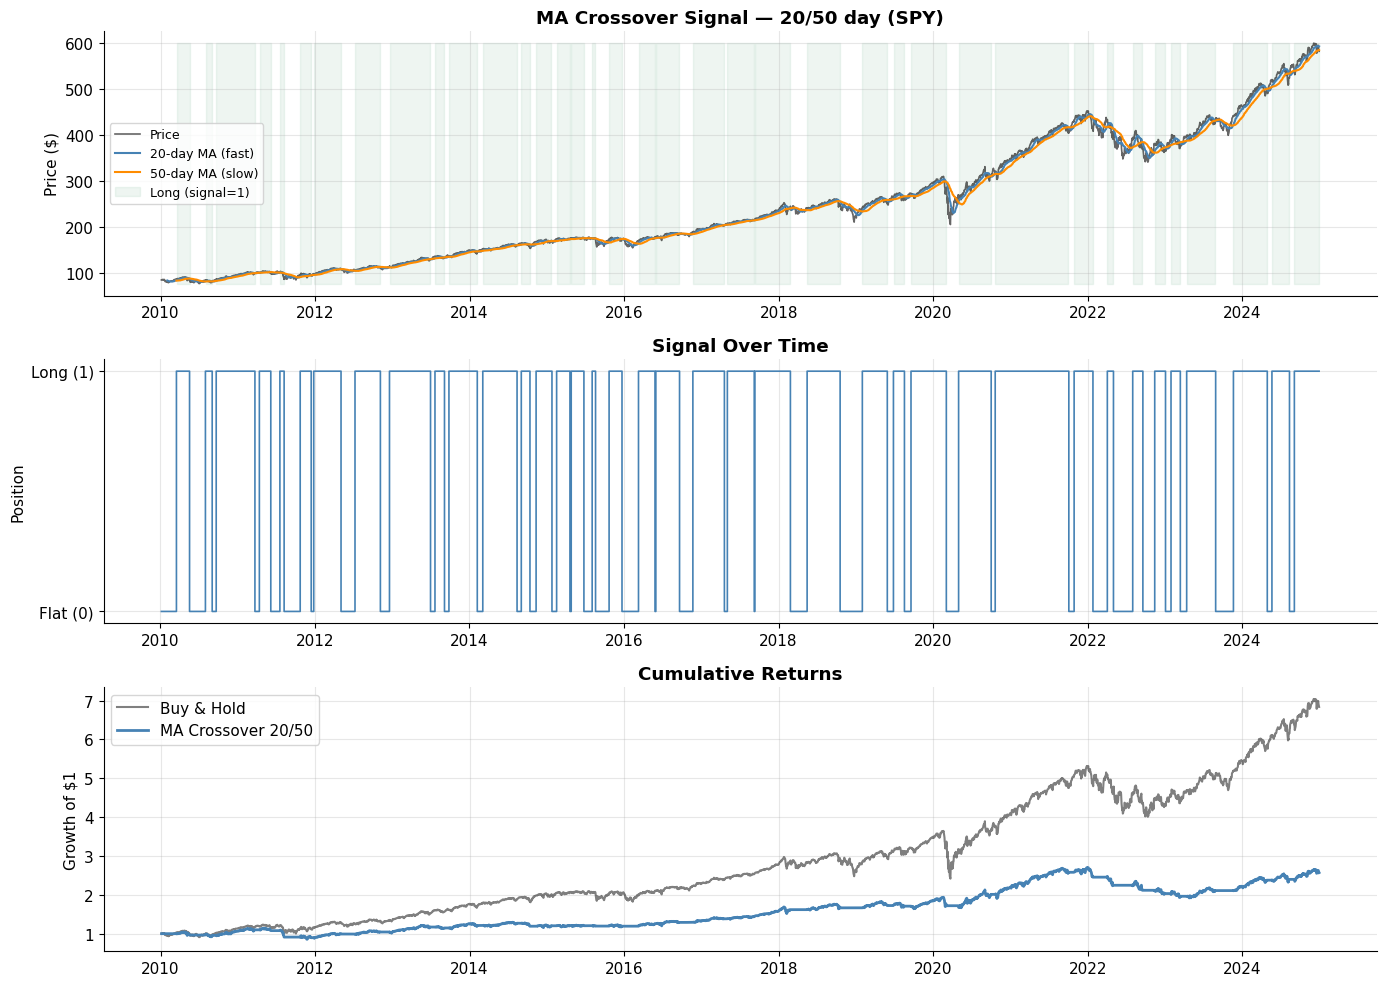


📋 PERFORMANCE
           Ann. Return Ann. Vol Sharpe Max Drawdown Hit Rate
Label                                                       
Buy & Hold       14.3%    17.1%   0.84       -33.7%    55.3%
MA 20/50          7.0%    11.6%   0.60       -28.9%    39.0%


In [3]:
def ma_crossover_signal(price, fast=20, slow=50):
    """
    Moving Average Crossover Signal.

    Hypothesis: when fast MA > slow MA, trend is up — go long.
                when fast MA < slow MA, trend is down — go flat.

    CRITICAL IMPLEMENTATION NOTE:
    The signal is shifted by 1 day (.shift(1)) before multiplying by returns.
    This means: the signal computed at close of day t is applied to the
    return ON day t+1 (i.e. from close t to close t+1).

    Without shift(1): you are using today's close to trade today's close —
    impossible in practice. This is look-ahead bias.

    Parameters
    ----------
    price : pd.Series  — daily close prices
    fast  : int        — fast MA window (days)
    slow  : int        — slow MA window (days)

    Returns
    -------
    signal   : pd.Series  — 1 (long) or 0 (flat), shifted by 1 day
    fast_ma  : pd.Series  — fast moving average
    slow_ma  : pd.Series  — slow moving average
    """
    assert fast < slow, f'fast ({fast}) must be < slow ({slow})'

    fast_ma = price.rolling(fast).mean()
    slow_ma = price.rolling(slow).mean()

    # Raw signal: 1 when fast > slow, 0 otherwise
    raw_signal = (fast_ma > slow_ma).astype(int)

    # ⚠️  SHIFT BY 1: signal computed at close of day t, applied to return of day t+1
    signal = raw_signal.shift(1)

    return signal, fast_ma, slow_ma


# Run baseline strategy
FAST, SLOW = 20, 50
signal_ma, fast_ma, slow_ma = ma_crossover_signal(price, fast=FAST, slow=SLOW)
strat_returns_ma = signal_ma * returns

# ── Visualise signal and price ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price + MAs
axes[0].plot(price,    color='black',      lw=1.2, alpha=0.6, label='Price')
axes[0].plot(fast_ma,  color='steelblue',  lw=1.5, label=f'{FAST}-day MA (fast)')
axes[0].plot(slow_ma,  color='darkorange', lw=1.5, label=f'{SLOW}-day MA (slow)')

# Shade long periods
axes[0].fill_between(price.index, price.min(), price.max(),
                     where=(signal_ma == 1),
                     alpha=0.08, color='seagreen', label='Long (signal=1)')
axes[0].set_title(f'MA Crossover Signal — {FAST}/{SLOW} day (SPY)', fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)

# Signal over time
axes[1].step(signal_ma.index, signal_ma, where='post', color='steelblue', lw=1.2)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Flat (0)', 'Long (1)'])
axes[1].set_title('Signal Over Time', fontweight='bold')
axes[1].set_ylabel('Position')

# Cumulative returns
cum_bh = (1 + returns).cumprod()
cum_ma = (1 + strat_returns_ma).cumprod()
axes[2].plot(cum_bh, color='black',     lw=1.5, alpha=0.5, label='Buy & Hold')
axes[2].plot(cum_ma, color='steelblue', lw=2,   label=f'MA Crossover {FAST}/{SLOW}')
axes[2].set_title('Cumulative Returns', fontweight='bold')
axes[2].set_ylabel('Growth of $1')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\n📋 PERFORMANCE')
stats_bh = summary_stats(returns,           'Buy & Hold')
stats_ma = summary_stats(strat_returns_ma,  f'MA {FAST}/{SLOW}')
print(pd.DataFrame([stats_bh, stats_ma]).set_index('Label').to_string())

### 2.2 — Signal Variants: The Same Hypothesis, Different Implementations

The MA crossover hypothesis can be implemented in many ways.  
Each variant encodes a slightly different assumption — and produces different results.

| Variant | Implementation | What it assumes |
|---------|---------------|----------------|
| **Binary** | 0 or 1 | Hard position change at crossover |
| **Graded** | Continuous 0–1 based on MA gap | Larger gap = stronger trend = larger position |
| **EMA** | Exponential instead of simple MA | Recent prices matter more |
| **Long/Short** | -1 or +1 | Always in market, reverse on crossover |

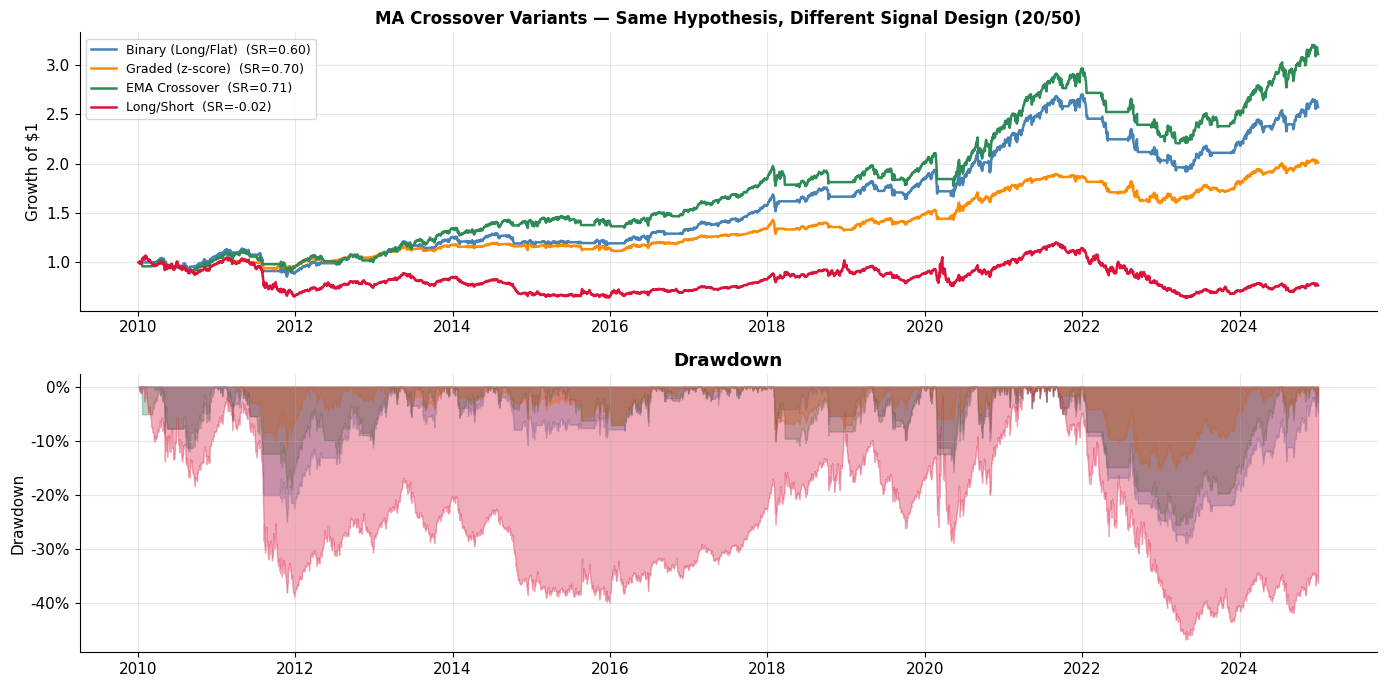


📋 VARIANT COMPARISON
                   Ann. Return Ann. Vol Sharpe Max Drawdown Hit Rate
Label                                                               
Binary (Long/Flat)        7.0%    11.6%   0.60       -28.9%    39.0%
Graded (z-score)          5.4%     7.7%   0.70       -15.5%    51.0%
EMA Crossover             8.3%    11.7%   0.71       -25.5%    43.7%
Long/Short               -0.3%    17.1%  -0.02       -46.7%    51.6%

📌 KEY OBSERVATION:
   Same hypothesis. Same MA windows. Very different Sharpe ratios.
   The signal design IS a modelling assumption that changes your results.


In [4]:
def ma_variants(price, returns, fast=20, slow=50):
    """
    Four implementations of the same MA crossover hypothesis.
    All use shift(1) to prevent look-ahead bias.
    """
    # ── Variant 1: Binary (simple, hard switch) ───────────────────────────────
    sma_f = price.rolling(fast).mean()
    sma_s = price.rolling(slow).mean()
    sig_binary = (sma_f > sma_s).astype(int).shift(1)

    # ── Variant 2: Graded by MA gap (position proportional to conviction) ─────
    # Gap = (fast_MA - slow_MA) / slow_MA  → normalised spread
    # Scale to [-1, +1] using rolling z-score
    gap    = (sma_f - sma_s) / sma_s
    gap_z  = (gap - gap.rolling(252).mean()) / gap.rolling(252).std()
    # Clip to [-2, 2] and rescale to [0, 1]
    sig_graded = (gap_z.clip(-2, 2) / 4 + 0.5).shift(1)

    # ── Variant 3: EMA instead of SMA ─────────────────────────────────────────
    ema_f = price.ewm(span=fast, adjust=False).mean()
    ema_s = price.ewm(span=slow, adjust=False).mean()
    sig_ema = (ema_f > ema_s).astype(int).shift(1)

    # ── Variant 4: Long/Short (always invested, reverse on crossover) ─────────
    # Signal = +1 (long) or -1 (short)
    sig_ls = ((sma_f > sma_s).astype(int) * 2 - 1).shift(1)

    # Compute returns
    r_binary = sig_binary * returns
    r_graded = sig_graded * returns
    r_ema    = sig_ema    * returns
    r_ls     = sig_ls     * returns

    return {
        'Binary (Long/Flat)': r_binary,
        'Graded (z-score)':   r_graded,
        'EMA Crossover':      r_ema,
        'Long/Short':         r_ls,
    }


variant_returns = ma_variants(price, returns, fast=FAST, slow=SLOW)

plot_strategy(variant_returns,
              title=f'MA Crossover Variants — Same Hypothesis, Different Signal Design ({FAST}/{SLOW})')

print('\n📋 VARIANT COMPARISON')
rows = [summary_stats(r, label) for label, r in variant_returns.items()]
print(pd.DataFrame(rows).set_index('Label').to_string())

print('\n📌 KEY OBSERVATION:')
print('   Same hypothesis. Same MA windows. Very different Sharpe ratios.')
print('   The signal design IS a modelling assumption that changes your results.')

---
## 📉 Module 3 — Mean Reversion

### 3.0 — The Hypothesis

> *When an asset's price deviates significantly from its recent average, it tends to revert back toward the mean. We should fade the move — sell when it's too far above average, buy when it's too far below.*

This is the **opposite** of the MA crossover hypothesis. Where trend-following says "momentum persists", mean reversion says "extremes revert".

**When does mean reversion work?**
- Low-volatility, range-bound markets
- Overreaction to news
- Statistical pairs or spreads

**When does it fail?**
- Trending markets (you keep fighting a trend that doesn't revert)
- Structural breaks (price moves to a new regime, never reverts)

**Explicit Assumptions:**
```
ASSUMPTION 1: Prices are stationary around a rolling mean (not a random walk)
ASSUMPTION 2: We define "extreme" via a rolling z-score
ASSUMPTION 3: We enter when |z| > entry_threshold, exit when |z| < exit_threshold
ASSUMPTION 4: Signal is computed on close, executed at next day open (shift(1))
```

### 3.1 — Z-Score Signal

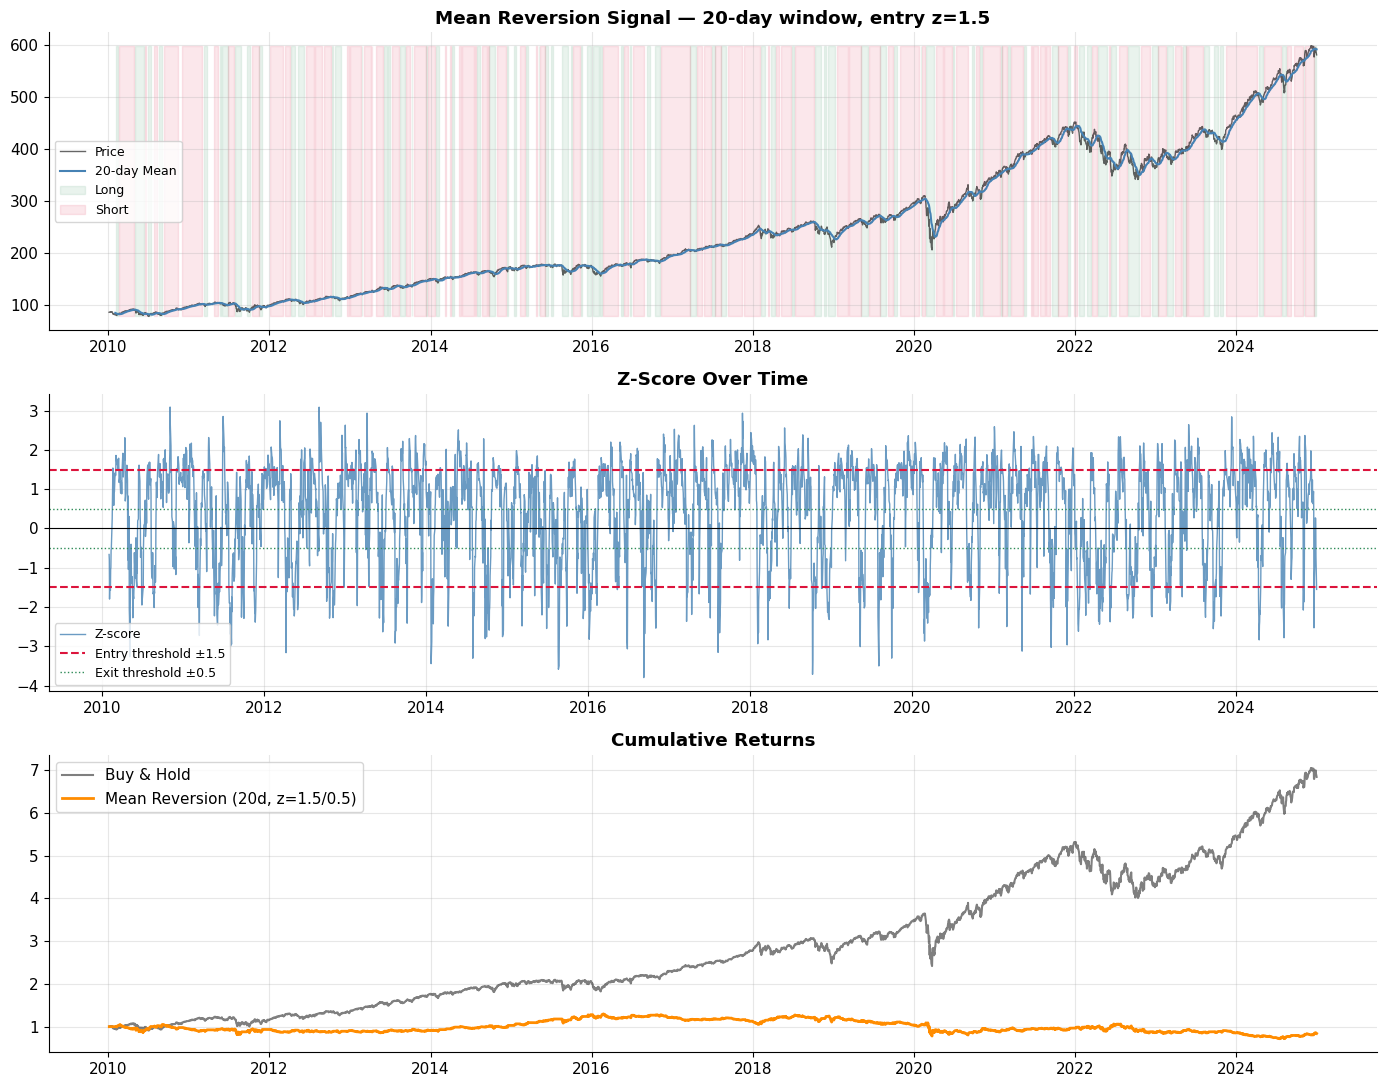

Label           Mean Reversion z=1.5/0.5
Ann. Return                         0.0%
Ann. Vol                           15.4%
Sharpe                              0.00
Max Drawdown                      -44.8%
Hit Rate                           37.6%


In [5]:
def zscore_signal(price, window=20, entry_z=1.5, exit_z=0.5):
    """
    Mean Reversion Signal via Rolling Z-Score.

    z_t = (price_t - rolling_mean_t) / rolling_std_t

    Entry/exit logic (with hysteresis to reduce churn):
      z < -entry_z  → go long  (price is too low, expect reversion up)
      z > +entry_z  → go short (price is too high, expect reversion down)
      |z| < exit_z  → exit to flat

    Parameters
    ----------
    price    : pd.Series
    window   : int   — rolling window for mean and std
    entry_z  : float — z-score threshold to enter position
    exit_z   : float — z-score threshold to exit position (< entry_z for hysteresis)
    """
    roll_mean = price.rolling(window).mean()
    roll_std  = price.rolling(window).std()
    z         = (price - roll_mean) / roll_std

    # Stateful signal: track position with hysteresis
    # 0 = flat, +1 = long, -1 = short
    signal = np.zeros(len(z))
    pos    = 0

    for i in range(1, len(z)):
        zi = z.iloc[i]
        if np.isnan(zi):
            signal[i] = 0
            continue

        if pos == 0:   # flat: check for entry
            if zi < -entry_z:
                pos = 1    # price too low → long
            elif zi > entry_z:
                pos = -1   # price too high → short

        elif pos == 1:  # long: exit when z reverts above exit threshold
            if zi > exit_z:
                pos = 0

        elif pos == -1: # short: exit when z reverts below exit threshold (negated)
            if zi < -exit_z:
                pos = 0

        signal[i] = pos

    signal_series = pd.Series(signal, index=z.index)

    # shift(1): signal at close t → trade at close t+1
    return signal_series.shift(1), z


# Baseline mean reversion
MR_WINDOW  = 20
ENTRY_Z    = 1.5
EXIT_Z     = 0.5

signal_mr, zscore = zscore_signal(price, window=MR_WINDOW,
                                   entry_z=ENTRY_Z, exit_z=EXIT_Z)
strat_returns_mr  = signal_mr * returns

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Price with entry/exit markers
axes[0].plot(price, color='black', lw=1, alpha=0.6, label='Price')
axes[0].plot(price.rolling(MR_WINDOW).mean(), color='steelblue', lw=1.5,
             label=f'{MR_WINDOW}-day Mean')
long_mask  = signal_mr.shift(-1) == 1
short_mask = signal_mr.shift(-1) == -1
axes[0].fill_between(price.index, price.min(), price.max(),
                     where=long_mask,  alpha=0.1, color='seagreen', label='Long')
axes[0].fill_between(price.index, price.min(), price.max(),
                     where=short_mask, alpha=0.1, color='crimson',  label='Short')
axes[0].set_title(f'Mean Reversion Signal — {MR_WINDOW}-day window, entry z={ENTRY_Z}',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Z-score with entry/exit bands
axes[1].plot(zscore, color='steelblue', lw=1, alpha=0.8, label='Z-score')
axes[1].axhline( ENTRY_Z, color='crimson',  lw=1.5, linestyle='--',
                 label=f'Entry threshold ±{ENTRY_Z}')
axes[1].axhline(-ENTRY_Z, color='crimson',  lw=1.5, linestyle='--')
axes[1].axhline( EXIT_Z,  color='seagreen', lw=1,   linestyle=':',
                 label=f'Exit threshold ±{EXIT_Z}')
axes[1].axhline(-EXIT_Z,  color='seagreen', lw=1,   linestyle=':')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Z-Score Over Time', fontweight='bold')
axes[1].legend(fontsize=9)

# Cumulative returns
axes[2].plot((1 + returns).cumprod(),          color='black',     lw=1.5,
             alpha=0.5, label='Buy & Hold')
axes[2].plot((1 + strat_returns_mr).cumprod(), color='darkorange', lw=2,
             label=f'Mean Reversion ({MR_WINDOW}d, z={ENTRY_Z}/{EXIT_Z})')
axes[2].set_title('Cumulative Returns', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(summary_stats(strat_returns_mr, f'Mean Reversion z={ENTRY_Z}/{EXIT_Z}').to_string())

### 3.2 — The Threshold Effect: Small Changes in Entry Z Produce Big Changes in Results

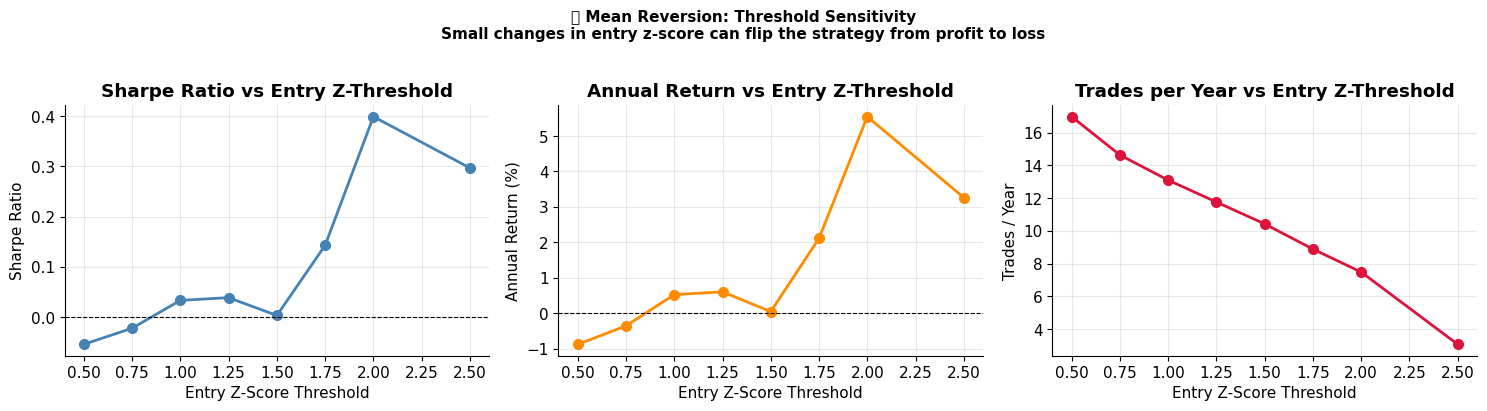

         Sharpe  Ann. Return  Max DD  N Trades/Yr
Entry Z                                          
0.50     -0.054       -0.009  -0.570       16.969
0.75     -0.022       -0.004  -0.547       14.631
1.00      0.033        0.005  -0.494       13.094
1.25      0.039        0.006  -0.492       11.758
1.50      0.003        0.000  -0.448       10.422
1.75      0.143        0.021  -0.336        8.885
2.00      0.399        0.055  -0.301        7.483
2.50      0.297        0.033  -0.283        3.073

📌 KEY OBSERVATION:
   The Sharpe ratio is NOT monotone in entry threshold.
   There is a "sweet spot" — but it is data-specific and likely to shift out-of-sample.


In [6]:
entry_z_range = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
threshold_results = []

for ez in entry_z_range:
    sig, _ = zscore_signal(price, window=MR_WINDOW, entry_z=ez, exit_z=ez * 0.33)
    r      = sig * returns
    n_trades = int(sig.diff().abs().sum() / 2)
    threshold_results.append({
        'Entry Z':      ez,
        'Sharpe':       sharpe(r),
        'Ann. Return':  ann_return(r),
        'Max DD':       max_drawdown(r),
        'N Trades/Yr':  n_trades / (len(r) / 252)
    })

thresh_df = pd.DataFrame(threshold_results).set_index('Entry Z')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(thresh_df.index, thresh_df['Sharpe'], 'o-',
             color='steelblue', lw=2, markersize=7)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Sharpe Ratio vs Entry Z-Threshold', fontweight='bold')
axes[0].set_xlabel('Entry Z-Score Threshold')
axes[0].set_ylabel('Sharpe Ratio')

axes[1].plot(thresh_df.index, thresh_df['Ann. Return'] * 100, 'o-',
             color='darkorange', lw=2, markersize=7)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Annual Return vs Entry Z-Threshold', fontweight='bold')
axes[1].set_xlabel('Entry Z-Score Threshold')
axes[1].set_ylabel('Annual Return (%)')

axes[2].plot(thresh_df.index, thresh_df['N Trades/Yr'], 'o-',
             color='crimson', lw=2, markersize=7)
axes[2].set_title('Trades per Year vs Entry Z-Threshold', fontweight='bold')
axes[2].set_xlabel('Entry Z-Score Threshold')
axes[2].set_ylabel('Trades / Year')

plt.suptitle('📌 Mean Reversion: Threshold Sensitivity\n'
             'Small changes in entry z-score can flip the strategy from profit to loss',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(thresh_df.round(3).to_string())
print('\n📌 KEY OBSERVATION:')
print('   The Sharpe ratio is NOT monotone in entry threshold.')
print('   There is a "sweet spot" — but it is data-specific and likely to shift out-of-sample.')

---
## 💥 Module 4 — Volatility Breakout

### 4.0 — The Hypothesis

> *When price breaks out of its recent trading range by more than usual — measured relative to recent volatility — it signals the start of a directional move. We should trade in the direction of the breakout.*

This is a **volatility-adjusted breakout** strategy. The key insight over a simple price channel is that a large absolute move means something different in a calm market vs a turbulent market. Normalising by volatility (via ATR) makes the signal regime-invariant.

**Explicit Assumptions:**
```
ASSUMPTION 1: ATR is computed from high/low/close (Wilder's definition)
ASSUMPTION 2: Breakout channel = rolling highest high / lowest low over N days
ASSUMPTION 3: Signal confirmed only when close > channel ± ATR multiplier
ASSUMPTION 4: Signal at close t → trade at close t+1 (shift(1))
ASSUMPTION 5: Exit when price falls back inside the channel
```

### 4.1 — ATR and Channel Implementation

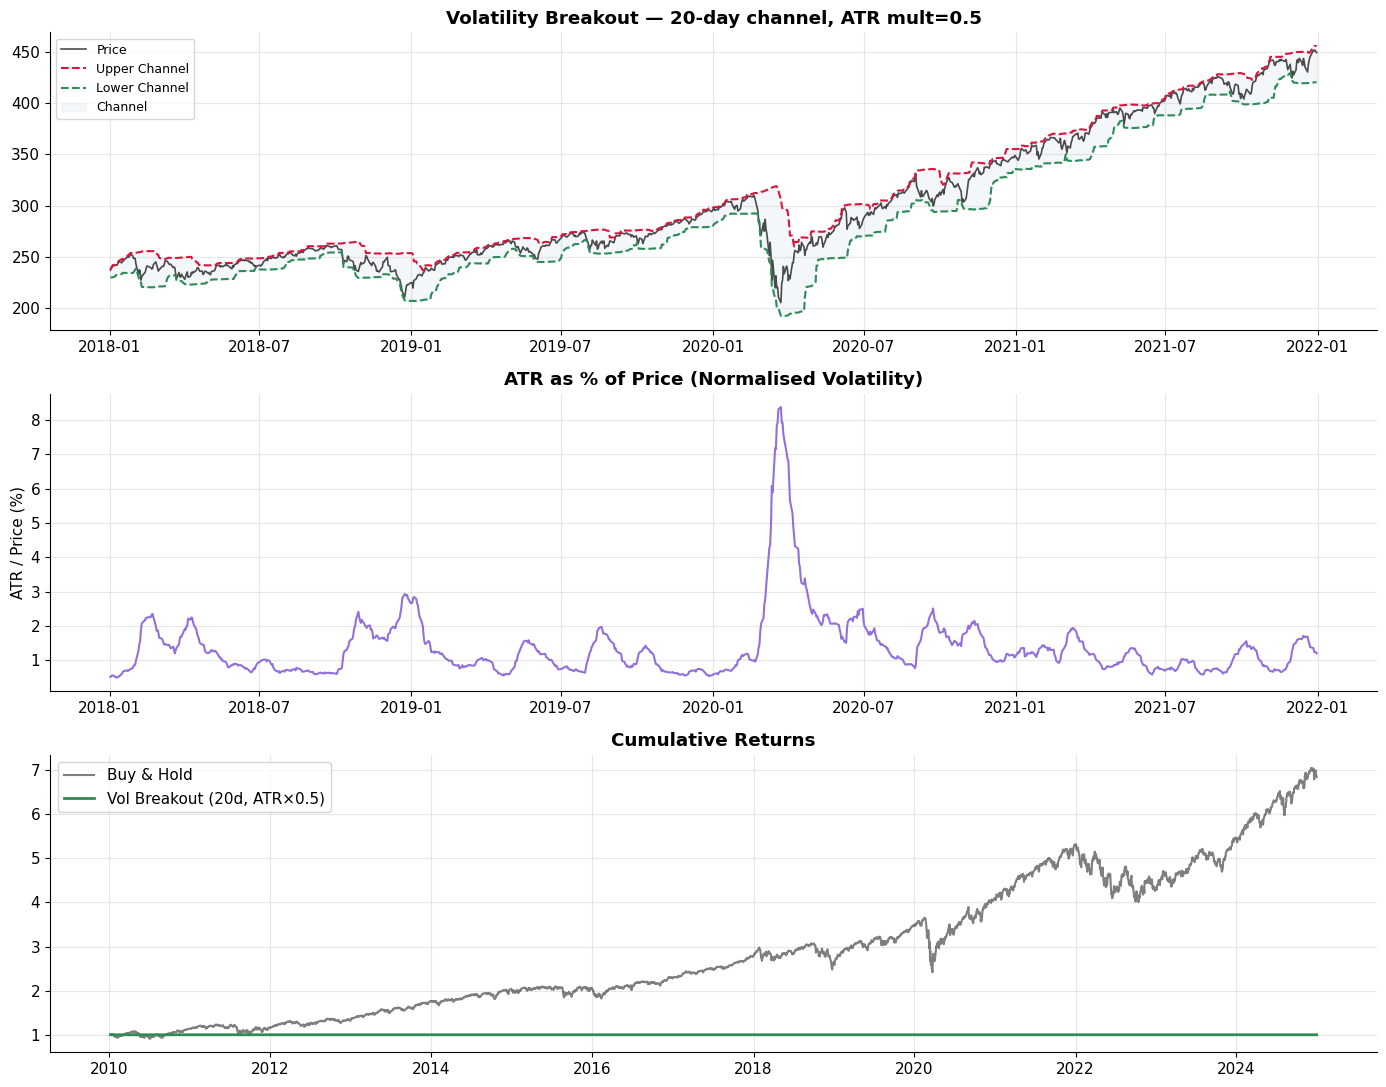

Label           Vol Breakout 20d ATR×0.5
Ann. Return                         0.0%
Ann. Vol                            0.0%
Sharpe                              0.00
Max Drawdown                        0.0%
Hit Rate                            0.0%


In [7]:
def atr(high, low, close, window=14):
    """
    Average True Range (Wilder 1978).
    True Range = max(high-low, |high-prev_close|, |low-prev_close|)
    ATR = rolling mean of True Range
    """
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(window).mean()


def volatility_breakout_signal(price, high, low, channel_window=20,
                                atr_window=14, atr_mult=0.5):
    """
    Volatility Breakout Signal.

    Logic:
      Upper channel = rolling_max(high, channel_window) + atr_mult * ATR
      Lower channel = rolling_min(low,  channel_window) - atr_mult * ATR

      Breakout UP:   close > upper channel → signal = +1 (long)
      Breakout DOWN: close < lower channel → signal = -1 (short)
      Inside channel:                      → signal = 0  (flat)

    The ATR multiplier controls how much of a breakout is needed:
      atr_mult = 0 → standard Donchian channel
      atr_mult > 0 → requires a larger breakout, reducing false signals
    """
    atr_series    = atr(high, low, price, window=atr_window)
    upper_channel = high.rolling(channel_window).max() + atr_mult * atr_series
    lower_channel = low.rolling(channel_window).min()  - atr_mult * atr_series

    signal = pd.Series(0, index=price.index, dtype=float)
    signal[price > upper_channel] =  1
    signal[price < lower_channel] = -1

    # shift(1): signal at close t → position from close t to close t+1
    return signal.shift(1), upper_channel, lower_channel, atr_series


CH_WINDOW = 20
ATR_MULT  = 0.5

signal_vb, upper_ch, lower_ch, atr_series = volatility_breakout_signal(
    price, high, low, channel_window=CH_WINDOW, atr_mult=ATR_MULT
)
strat_returns_vb = signal_vb * returns

# ── Visualise — use a 2-year window for clarity ───────────────────────────────
ZOOM_START = '2018-01-01'
ZOOM_END   = '2021-12-31'
zm = slice(ZOOM_START, ZOOM_END)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

axes[0].plot(price[zm],       color='black',     lw=1.2, alpha=0.7, label='Price')
axes[0].plot(upper_ch[zm],    color='crimson',   lw=1.5, linestyle='--', label='Upper Channel')
axes[0].plot(lower_ch[zm],    color='seagreen',  lw=1.5, linestyle='--', label='Lower Channel')
axes[0].fill_between(upper_ch[zm].index, upper_ch[zm], lower_ch[zm],
                     alpha=0.06, color='steelblue', label='Channel')
axes[0].set_title(f'Volatility Breakout — {CH_WINDOW}-day channel, ATR mult={ATR_MULT}',
                  fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(atr_series[zm] / price[zm] * 100, color='mediumpurple', lw=1.5)
axes[1].set_title('ATR as % of Price (Normalised Volatility)', fontweight='bold')
axes[1].set_ylabel('ATR / Price (%)')

axes[2].plot((1 + returns).cumprod(),          color='black',     lw=1.5, alpha=0.5,
             label='Buy & Hold')
axes[2].plot((1 + strat_returns_vb).cumprod(), color='seagreen',  lw=2,
             label=f'Vol Breakout ({CH_WINDOW}d, ATR×{ATR_MULT})')
axes[2].set_title('Cumulative Returns', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(summary_stats(strat_returns_vb, f'Vol Breakout {CH_WINDOW}d ATR×{ATR_MULT}').to_string())

---
## 🗺️ Module 5 — Parameter Sensitivity

### Why Parameter Sensitivity Matters More Than the Best Parameter

Finding the parameter that maximised Sharpe ratio over your backtest period is easy.  
It tells you almost nothing useful.

What tells you something useful is whether the strategy works **robustly across a wide range of parameters**. A strategy with a sharp, narrow performance peak is almost certainly overfit to the specific historical path. A strategy with a broad, stable plateau is more likely to reflect a genuine structural edge.

> *The best parameter is not the parameter that performed best. It is the centre of the region where performance is stable.*

We will build **2D Sharpe ratio heatmaps** for each strategy.

Running MA crossover parameter grid...


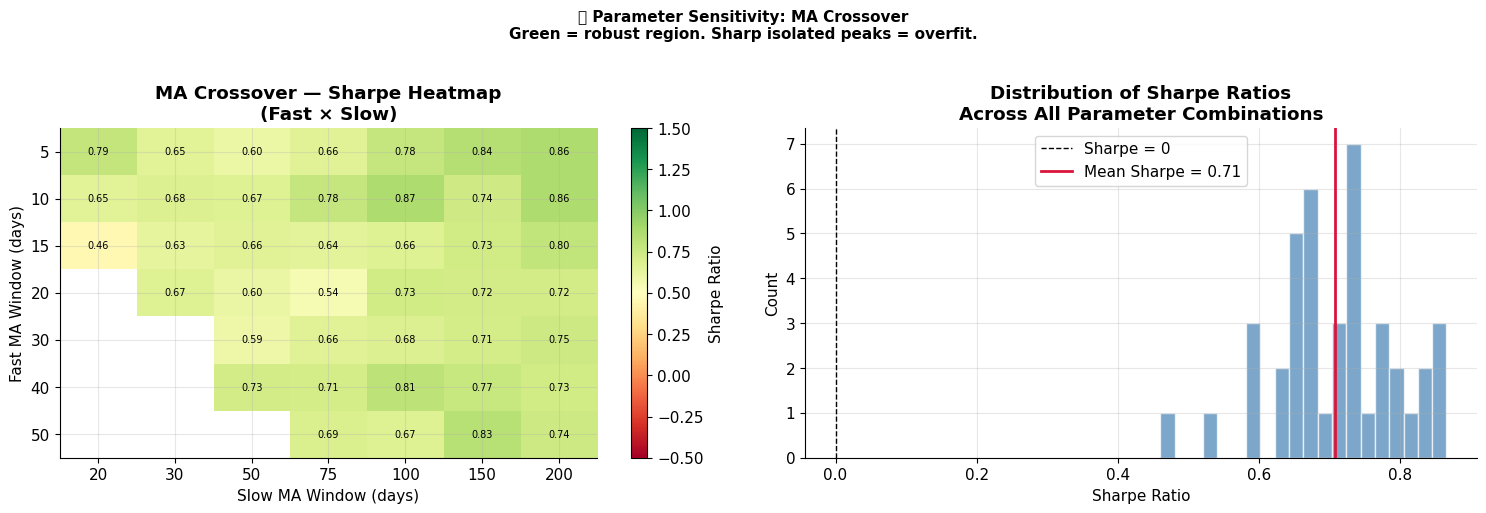

Best parameter: fast=10, slow=100  Sharpe=0.87
Mean Sharpe across all 41 combinations: 0.71
% of combinations with positive Sharpe: 100%

📌 If the mean is strongly positive and the map is broadly green,
   the strategy has structural merit. If only a few cells are green,
   it is likely overfit to those specific parameters.


In [8]:
# ── MA Crossover: 2D grid over fast × slow ────────────────────────────────────
fast_range = [5, 10, 15, 20, 30, 40, 50]
slow_range = [20, 30, 50, 75, 100, 150, 200]

valid_pairs   = [(f, s) for f in fast_range for s in slow_range if f < s]
ma_grid_results = {}

print('Running MA crossover parameter grid...')
for fast, slow in valid_pairs:
    sig, _, _ = ma_crossover_signal(price, fast=fast, slow=slow)
    r         = sig * returns
    ma_grid_results[(fast, slow)] = sharpe(r)

# Build Sharpe matrix for heatmap
ma_sharpe_matrix = pd.DataFrame(index=fast_range, columns=slow_range, dtype=float)
for (f, s), sr in ma_grid_results.items():
    ma_sharpe_matrix.loc[f, s] = sr

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im1 = axes[0].imshow(ma_sharpe_matrix.values.astype(float),
                     cmap='RdYlGn', aspect='auto',
                     vmin=-0.5, vmax=1.5)
plt.colorbar(im1, ax=axes[0], label='Sharpe Ratio')
axes[0].set_xticks(range(len(slow_range))); axes[0].set_xticklabels(slow_range)
axes[0].set_yticks(range(len(fast_range))); axes[0].set_yticklabels(fast_range)
axes[0].set_xlabel('Slow MA Window (days)')
axes[0].set_ylabel('Fast MA Window (days)')
axes[0].set_title('MA Crossover — Sharpe Heatmap\n(Fast × Slow)', fontweight='bold')
# Annotate cells
for i, f in enumerate(fast_range):
    for j, s in enumerate(slow_range):
        v = ma_sharpe_matrix.loc[f, s]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                         color='black' if abs(v) < 1.0 else 'white')

# Distribution of Sharpe ratios across parameter space
all_sharpes = [v for v in ma_grid_results.values() if not np.isnan(v)]
axes[1].hist(all_sharpes, bins=20, color='steelblue', alpha=0.7, edgecolor='white', lw=0.3)
axes[1].axvline(0, color='black', lw=1, linestyle='--', label='Sharpe = 0')
axes[1].axvline(np.mean(all_sharpes), color='crimson', lw=2,
                label=f'Mean Sharpe = {np.mean(all_sharpes):.2f}')
axes[1].set_title('Distribution of Sharpe Ratios\nAcross All Parameter Combinations',
                  fontweight='bold')
axes[1].set_xlabel('Sharpe Ratio')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('📌 Parameter Sensitivity: MA Crossover\n'
             'Green = robust region. Sharp isolated peaks = overfit.',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_pair = max(ma_grid_results, key=ma_grid_results.get)
print(f'Best parameter: fast={best_pair[0]}, slow={best_pair[1]}  Sharpe={ma_grid_results[best_pair]:.2f}')
print(f'Mean Sharpe across all {len(all_sharpes)} combinations: {np.mean(all_sharpes):.2f}')
print(f'% of combinations with positive Sharpe: {np.mean([s > 0 for s in all_sharpes]):.0%}')
print()
print('📌 If the mean is strongly positive and the map is broadly green,')
print('   the strategy has structural merit. If only a few cells are green,')
print('   it is likely overfit to those specific parameters.')

Running Vol Breakout parameter grid...


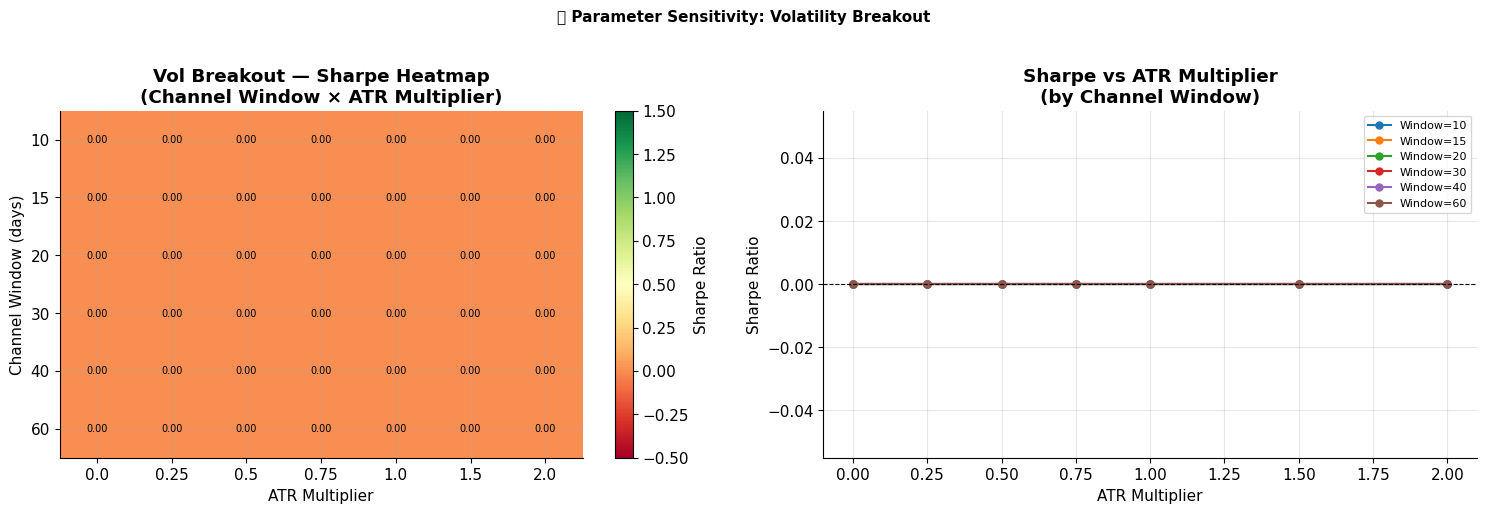

In [9]:
# ── Volatility Breakout: 2D grid over channel_window × atr_mult ───────────────
ch_windows = [10, 15, 20, 30, 40, 60]
atr_mults  = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

vb_grid = pd.DataFrame(index=ch_windows, columns=atr_mults, dtype=float)

print('Running Vol Breakout parameter grid...')
for cw in ch_windows:
    for am in atr_mults:
        sig, _, _, _ = volatility_breakout_signal(price, high, low,
                                                   channel_window=cw, atr_mult=am)
        r                  = sig * returns
        vb_grid.loc[cw, am] = sharpe(r)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im2 = axes[0].imshow(vb_grid.values.astype(float), cmap='RdYlGn',
                     aspect='auto', vmin=-0.5, vmax=1.5)
plt.colorbar(im2, ax=axes[0], label='Sharpe Ratio')
axes[0].set_xticks(range(len(atr_mults)));  axes[0].set_xticklabels(atr_mults)
axes[0].set_yticks(range(len(ch_windows))); axes[0].set_yticklabels(ch_windows)
axes[0].set_xlabel('ATR Multiplier')
axes[0].set_ylabel('Channel Window (days)')
axes[0].set_title('Vol Breakout — Sharpe Heatmap\n(Channel Window × ATR Multiplier)',
                  fontweight='bold')
for i, cw in enumerate(ch_windows):
    for j, am in enumerate(atr_mults):
        v = vb_grid.loc[cw, am]
        if not np.isnan(v):
            axes[1-1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7)

# Slice: Sharpe vs ATR mult for different windows
for cw in ch_windows:
    axes[1].plot(atr_mults, vb_grid.loc[cw].values.astype(float),
                 'o-', lw=1.5, markersize=5, label=f'Window={cw}')
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Sharpe vs ATR Multiplier\n(by Channel Window)', fontweight='bold')
axes[1].set_xlabel('ATR Multiplier')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].legend(fontsize=8)

plt.suptitle('📌 Parameter Sensitivity: Volatility Breakout', fontsize=11,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## ⚠️ Module 6 — The Distortion Catalogue

### How Small Modelling Choices Bend Your Results

This is the most important module in the notebook. Each section below demonstrates a concrete implementation choice that is easy to get wrong and shows exactly how much it changes your Sharpe ratio.

These are not exotic edge cases. They are mistakes made in real backtests every day.

### 6.1 — Look-Ahead Bias: The Most Dangerous Mistake

**What it is:** Using information in your signal calculation that would not have been available at the time of the trade.

**The classic form:** Forgetting `.shift(1)`. Your signal is computed using today's close price and then you multiply it by today's close-to-close return — which means you are implicitly trading *before* today's close was known.

**Why it is so hard to spot:** The code runs, produces a result, and the result looks great. There is no error message. The only way to detect it is to reason carefully about the timing of each variable.


🔍 LOOK-AHEAD BIAS DEMONSTRATION

  ✅ Correct (shift+1):    Sharpe = 0.602   ← what you would actually get
  ❌ Biased  (no shift):   Sharpe = 0.721   ← inflated by ~0.118
  ❌ Extreme (shift-1):    Sharpe = 0.791   ← pure future knowledge, impossible

  Bias inflation (no shift vs correct): +20%


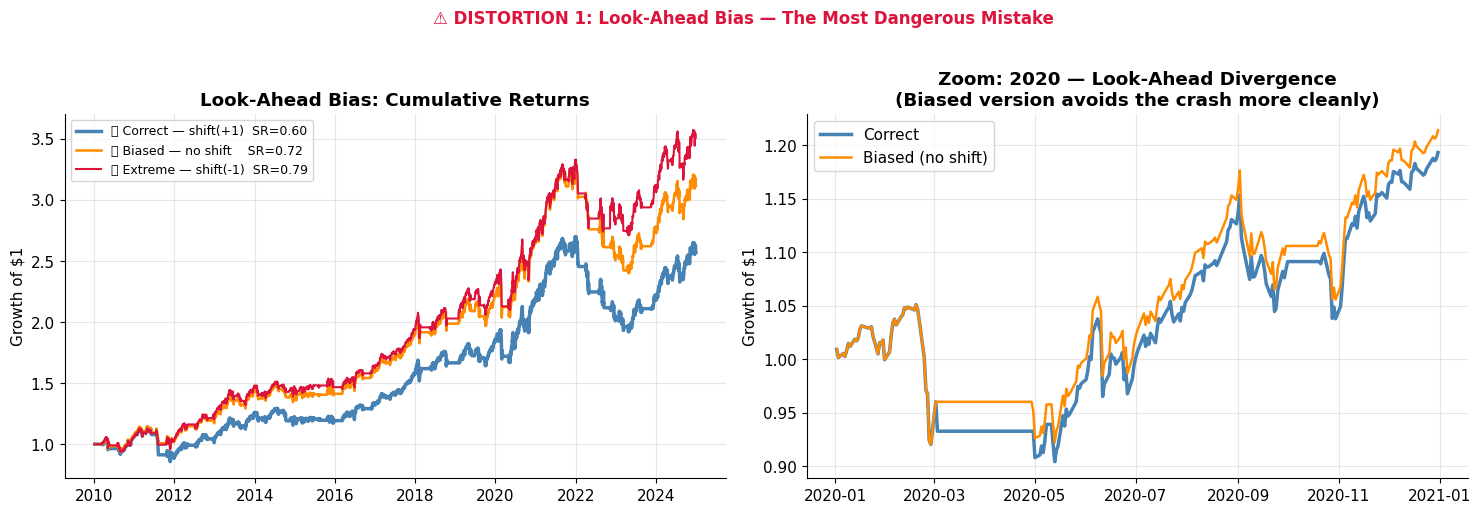

In [10]:
# Recreate the MA signal with and without look-ahead bias
fast_ma = price.rolling(FAST).mean()
slow_ma = price.rolling(SLOW).mean()
raw_signal = (fast_ma > slow_ma).astype(int)

# ✅ CORRECT: shift(1) — use yesterday's signal to trade today
sig_correct = raw_signal.shift(1)

# ❌ BIASED:  no shift — use today's signal to trade today (impossible in practice)
sig_biased  = raw_signal

# ❌ EXTREME: shift(-1) — use TOMORROW's signal to trade today (pure future peeking)
sig_extreme = raw_signal.shift(-1)

r_correct = sig_correct * returns
r_biased  = sig_biased  * returns
r_extreme = sig_extreme * returns

sr_correct = sharpe(r_correct)
sr_biased  = sharpe(r_biased)
sr_extreme = sharpe(r_extreme)

print('\n🔍 LOOK-AHEAD BIAS DEMONSTRATION\n')
print(f'  ✅ Correct (shift+1):    Sharpe = {sr_correct:.3f}   ← what you would actually get')
print(f'  ❌ Biased  (no shift):   Sharpe = {sr_biased:.3f}   ← inflated by ~{sr_biased - sr_correct:.3f}')
print(f'  ❌ Extreme (shift-1):    Sharpe = {sr_extreme:.3f}   ← pure future knowledge, impossible')
print()
print(f'  Bias inflation (no shift vs correct): +{(sr_biased - sr_correct)/sr_correct*100:.0f}%')

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for r, label, color, lw in [
    (r_correct, f'✅ Correct — shift(+1)  SR={sr_correct:.2f}', 'steelblue', 2.5),
    (r_biased,  f'❌ Biased — no shift    SR={sr_biased:.2f}',  'darkorange', 1.8),
    (r_extreme, f'❌ Extreme — shift(-1)  SR={sr_extreme:.2f}', 'crimson',    1.5),
]:
    axes[0].plot((1 + r).cumprod(), label=label, color=color, lw=lw)

axes[0].set_title('Look-Ahead Bias: Cumulative Returns', fontweight='bold')
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=9)

# Zoom in on one year to see the daily difference
zm = slice('2020-01-01', '2021-01-01')
axes[1].plot((1 + r_correct[zm]).cumprod(), color='steelblue',  lw=2.5,
             label='Correct')
axes[1].plot((1 + r_biased[zm]).cumprod(),  color='darkorange', lw=1.8,
             label='Biased (no shift)')
axes[1].set_title('Zoom: 2020 — Look-Ahead Divergence\n(Biased version avoids the crash more cleanly)',
                  fontweight='bold')
axes[1].set_ylabel('Growth of $1')
axes[1].legend()

plt.suptitle('⚠️ DISTORTION 1: Look-Ahead Bias — The Most Dangerous Mistake',
             fontsize=12, fontweight='bold', y=1.02, color='crimson')
plt.tight_layout()
plt.show()

### 6.2 — Transaction Costs: The Silent Alpha Killer

  Strategy trades 5.0 times per year

📋 PERFORMANCE BY TRANSACTION COST ASSUMPTION

        Sharpe  Ann Return
0 bps    0.602       0.070
2 bps    0.594       0.069
5 bps    0.581       0.067
10 bps   0.559       0.065
20 bps   0.516       0.060
50 bps   0.384       0.045


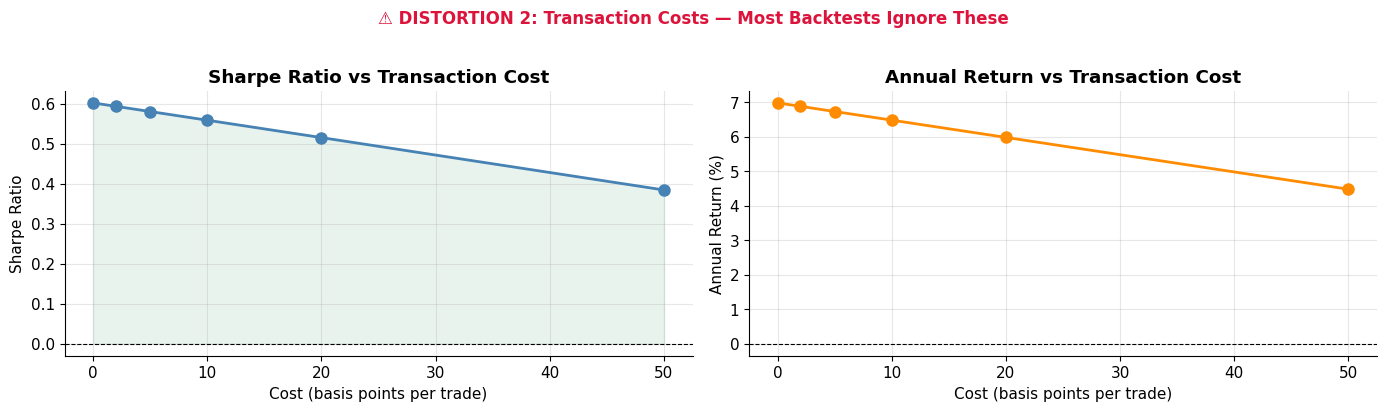

In [11]:
def apply_transaction_costs(signal, returns, cost_bps=10):
    """
    Apply proportional transaction costs on each position change.

    cost_bps : cost in basis points per round-trip trade
               1 bps = 0.01% of portfolio value
               Realistic range: 1–5 bps (institutional), 5–20 bps (retail)

    The cost is deducted from the return on the day a trade occurs.
    Turnover = absolute change in position from day t-1 to day t.
    """
    cost_daily  = cost_bps / 10000
    turnover    = signal.diff().abs().fillna(0)
    cost_series = turnover * cost_daily
    return (signal * returns) - cost_series


# Test across a range of cost assumptions
cost_levels = [0, 2, 5, 10, 20, 50]
cost_results = {}

sig_clean, _, _ = ma_crossover_signal(price, fast=FAST, slow=SLOW)
n_trades_yr = sig_clean.diff().abs().sum() / (len(sig_clean) / 252)

for bps in cost_levels:
    r = apply_transaction_costs(sig_clean, returns, cost_bps=bps)
    cost_results[f'{bps} bps'] = {'Sharpe': sharpe(r), 'Ann Return': ann_return(r)}

cost_df = pd.DataFrame(cost_results).T

print(f'  Strategy trades {n_trades_yr:.1f} times per year')
print()
print('📋 PERFORMANCE BY TRANSACTION COST ASSUMPTION\n')
print(cost_df.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

bps_vals = cost_levels
sharpes  = [cost_results[f'{b} bps']['Sharpe']     for b in bps_vals]
rets     = [cost_results[f'{b} bps']['Ann Return'] for b in bps_vals]

axes[0].plot(bps_vals, sharpes, 'o-', color='steelblue', lw=2, markersize=8)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Sharpe Ratio vs Transaction Cost', fontweight='bold')
axes[0].set_xlabel('Cost (basis points per trade)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].fill_between(bps_vals, sharpes, 0,
                     where=[s > 0 for s in sharpes], alpha=0.1, color='seagreen')
axes[0].fill_between(bps_vals, sharpes, 0,
                     where=[s <= 0 for s in sharpes], alpha=0.1, color='crimson')

axes[1].plot(bps_vals, [r*100 for r in rets], 'o-', color='darkorange', lw=2, markersize=8)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Annual Return vs Transaction Cost', fontweight='bold')
axes[1].set_xlabel('Cost (basis points per trade)')
axes[1].set_ylabel('Annual Return (%)')

plt.suptitle('⚠️ DISTORTION 2: Transaction Costs — Most Backtests Ignore These',
             fontsize=12, fontweight='bold', y=1.02, color='crimson')
plt.tight_layout()
plt.show()

# Break-even cost
if sharpes[0] > 0:
    breakeven_idx = next((i for i, s in enumerate(sharpes) if s <= 0), None)
    if breakeven_idx:
        print(f'\n📌 Strategy breaks even (Sharpe=0) at approximately {bps_vals[breakeven_idx]} bps per trade')
        print(f'   At {n_trades_yr:.0f} trades/year, total annual cost drag = {bps_vals[breakeven_idx] * n_trades_yr / 100:.2f}%')

### 6.3 — Signal Smoothing: Does It Help or Just Reduce Turnover?

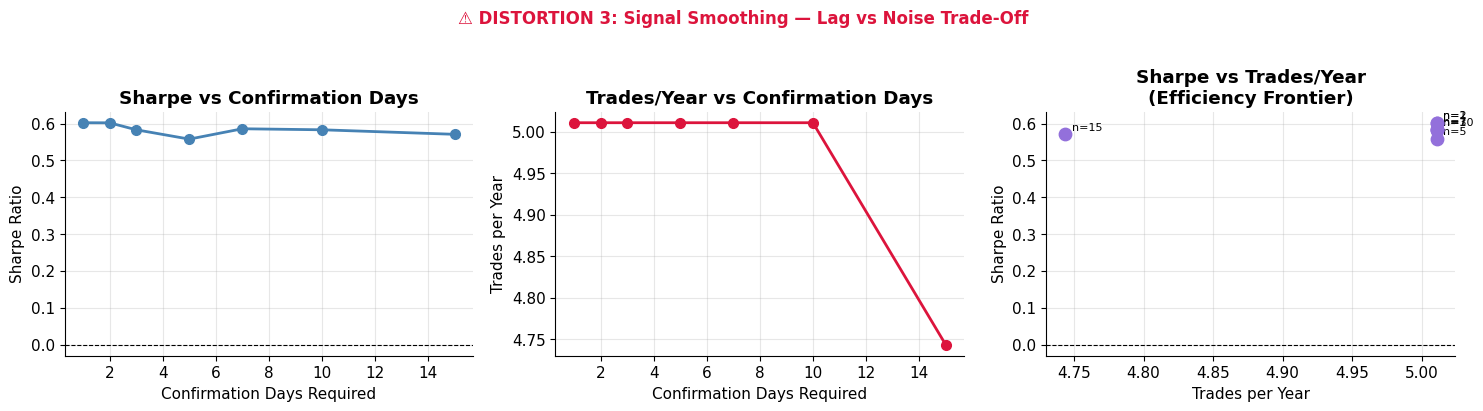

In [12]:
# A common "improvement": smooth the signal to reduce whipsaws
# e.g. only trade if the signal has been consistently positive for N days

def smoothed_signal(signal, confirmation_days=3):
    """
    Require signal to be consistently 1 (or 0) for `confirmation_days`
    before acting on it.

    This reduces turnover but introduces additional lag.
    The trade-off: fewer false signals vs slower reaction to trend changes.
    """
    # Rolling mean of signal: if mean == 1.0 for N days, confirmed long
    smoothed = (signal.rolling(confirmation_days).mean() == 1).astype(int)
    return smoothed


smooth_results = {}
confirmation_range = [1, 2, 3, 5, 7, 10, 15]

sig_base, _, _ = ma_crossover_signal(price, fast=FAST, slow=SLOW)

for n in confirmation_range:
    sig_s = smoothed_signal(sig_base, confirmation_days=n)
    r     = sig_s * returns
    to    = sig_s.diff().abs().sum() / (len(r) / 252)
    smooth_results[n] = {
        'Sharpe':        sharpe(r),
        'Ann Return':    ann_return(r),
        'Trades/Year':   to,
        'Avg Lag (days)': n
    }

smooth_df = pd.DataFrame(smooth_results).T

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(smooth_df.index, smooth_df['Sharpe'], 'o-',
             color='steelblue', lw=2, markersize=7)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_title('Sharpe vs Confirmation Days', fontweight='bold')
axes[0].set_xlabel('Confirmation Days Required')
axes[0].set_ylabel('Sharpe Ratio')

axes[1].plot(smooth_df.index, smooth_df['Trades/Year'], 'o-',
             color='crimson', lw=2, markersize=7)
axes[1].set_title('Trades/Year vs Confirmation Days', fontweight='bold')
axes[1].set_xlabel('Confirmation Days Required')
axes[1].set_ylabel('Trades per Year')

# Sharpe vs trades — the efficiency frontier
axes[2].scatter(smooth_df['Trades/Year'], smooth_df['Sharpe'],
                color='mediumpurple', s=80, zorder=5)
for n, row in smooth_df.iterrows():
    axes[2].annotate(f'n={n}', (row['Trades/Year'], row['Sharpe']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_title('Sharpe vs Trades/Year\n(Efficiency Frontier)', fontweight='bold')
axes[2].set_xlabel('Trades per Year')
axes[2].set_ylabel('Sharpe Ratio')

plt.suptitle('⚠️ DISTORTION 3: Signal Smoothing — Lag vs Noise Trade-Off',
             fontsize=12, fontweight='bold', y=1.02, color='crimson')
plt.tight_layout()
plt.show()

### 6.4 — In-Sample vs Out-of-Sample: The Overfitting Trap

**The most important test in all of strategy development.**

Any parameter that was selected by optimising over the full backtest is contaminated — you have fit to noise, not signal. The only honest test is to select parameters on one period and evaluate them on a completely separate period.

In-Sample:     2010-01-05 → 2018-12-31  (2263 days)
Out-of-Sample: 2019-01-02 → 2024-12-30  (1509 days)

Best IS parameter:   fast=40, slow=100   IS Sharpe=0.91
Median IS parameter: fast=15, slow=150 IS Sharpe=0.69
Worst IS parameter:  fast=5, slow=20  IS Sharpe=0.33

OOS performance of IS-best parameter:   Sharpe=0.72
OOS performance of IS-median parameter: Sharpe=0.75
OOS performance of IS-worst parameter:  Sharpe=1.29


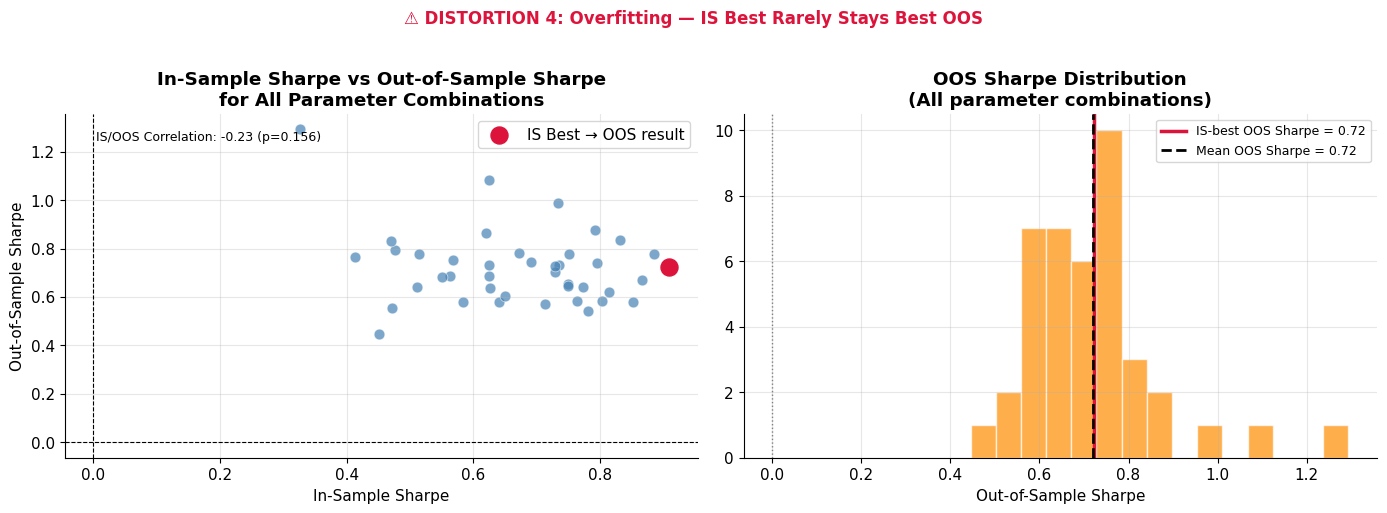


📌 KEY INSIGHT: If IS/OOS correlation is low, your parameter choice is noise.
   If the IS-best parameter performs near average OOS, you have overfit.
   Honest strategy evaluation ALWAYS uses a holdout set.


In [13]:
# Split data: in-sample (first 60%), out-of-sample (last 40%)
split_idx = int(len(price) * 0.6)
price_is  = price.iloc[:split_idx]
price_oos = price.iloc[split_idx:]
ret_is    = returns.iloc[:split_idx]
ret_oos   = returns.iloc[split_idx:]
high_oos  = high.iloc[split_idx:]
low_oos   = low.iloc[split_idx:]

print(f'In-Sample:     {price_is.index[0].date()} → {price_is.index[-1].date()}  ({len(price_is)} days)')
print(f'Out-of-Sample: {price_oos.index[0].date()} → {price_oos.index[-1].date()}  ({len(price_oos)} days)')

# Step 1: Find best parameters IN-SAMPLE
is_results = {}
for fast, slow in [(f, s) for f in fast_range for s in slow_range if f < s]:
    sig, _, _ = ma_crossover_signal(price_is, fast=fast, slow=slow)
    r = sig * ret_is
    is_results[(fast, slow)] = sharpe(r)

best_is   = max(is_results, key=is_results.get)
worst_is  = min(is_results, key=is_results.get)
median_is = sorted(is_results, key=is_results.get)[len(is_results)//2]

print(f'\nBest IS parameter:   fast={best_is[0]}, slow={best_is[1]}   IS Sharpe={is_results[best_is]:.2f}')
print(f'Median IS parameter: fast={median_is[0]}, slow={median_is[1]} IS Sharpe={is_results[median_is]:.2f}')
print(f'Worst IS parameter:  fast={worst_is[0]}, slow={worst_is[1]}  IS Sharpe={is_results[worst_is]:.2f}')

# Step 2: Apply to OUT-OF-SAMPLE
def oos_sharpe(params, price_oos, ret_oos):
    sig, _, _ = ma_crossover_signal(price_oos, fast=params[0], slow=params[1])
    return sharpe(sig * ret_oos)

sr_best_oos   = oos_sharpe(best_is,   price_oos, ret_oos)
sr_median_oos = oos_sharpe(median_is, price_oos, ret_oos)
sr_worst_oos  = oos_sharpe(worst_is,  price_oos, ret_oos)

print(f'\nOOS performance of IS-best parameter:   Sharpe={sr_best_oos:.2f}')
print(f'OOS performance of IS-median parameter: Sharpe={sr_median_oos:.2f}')
print(f'OOS performance of IS-worst parameter:  Sharpe={sr_worst_oos:.2f}')

# Distribution of OOS Sharpe for all IS-tested parameters
oos_sharpes_all = [oos_sharpe(p, price_oos, ret_oos) for p in is_results.keys()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(list(is_results.values()), oos_sharpes_all,
                alpha=0.7, color='steelblue', s=60, edgecolors='white', lw=0.5)
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].axvline(0, color='black', lw=0.8, linestyle='--')
axes[0].scatter([is_results[best_is]], [sr_best_oos],
                color='crimson', s=150, zorder=10, label='IS Best → OOS result')
axes[0].set_title('In-Sample Sharpe vs Out-of-Sample Sharpe\nfor All Parameter Combinations',
                  fontweight='bold')
axes[0].set_xlabel('In-Sample Sharpe')
axes[0].set_ylabel('Out-of-Sample Sharpe')
axes[0].legend()

# Correlation
corr, pval = stats.pearsonr(list(is_results.values()), oos_sharpes_all)
axes[0].text(0.05, 0.95, f'IS/OOS Correlation: {corr:.2f} (p={pval:.3f})',
             transform=axes[0].transAxes, fontsize=9, va='top')

# OOS Sharpe distribution
axes[1].hist(oos_sharpes_all, bins=15, color='darkorange', alpha=0.7,
             edgecolor='white', lw=0.3)
axes[1].axvline(sr_best_oos, color='crimson', lw=2.5,
                label=f'IS-best OOS Sharpe = {sr_best_oos:.2f}')
axes[1].axvline(np.mean(oos_sharpes_all), color='black', lw=2, linestyle='--',
                label=f'Mean OOS Sharpe = {np.mean(oos_sharpes_all):.2f}')
axes[1].axvline(0, color='gray', lw=1, linestyle=':')
axes[1].set_title('OOS Sharpe Distribution\n(All parameter combinations)',
                  fontweight='bold')
axes[1].set_xlabel('Out-of-Sample Sharpe')
axes[1].legend(fontsize=9)

plt.suptitle('⚠️ DISTORTION 4: Overfitting — IS Best Rarely Stays Best OOS',
             fontsize=12, fontweight='bold', y=1.02, color='crimson')
plt.tight_layout()
plt.show()

print()
print('📌 KEY INSIGHT: If IS/OOS correlation is low, your parameter choice is noise.')
print('   If the IS-best parameter performs near average OOS, you have overfit.')
print('   Honest strategy evaluation ALWAYS uses a holdout set.')

### 6.5 — Four More Distortions (Quick Demonstrations)

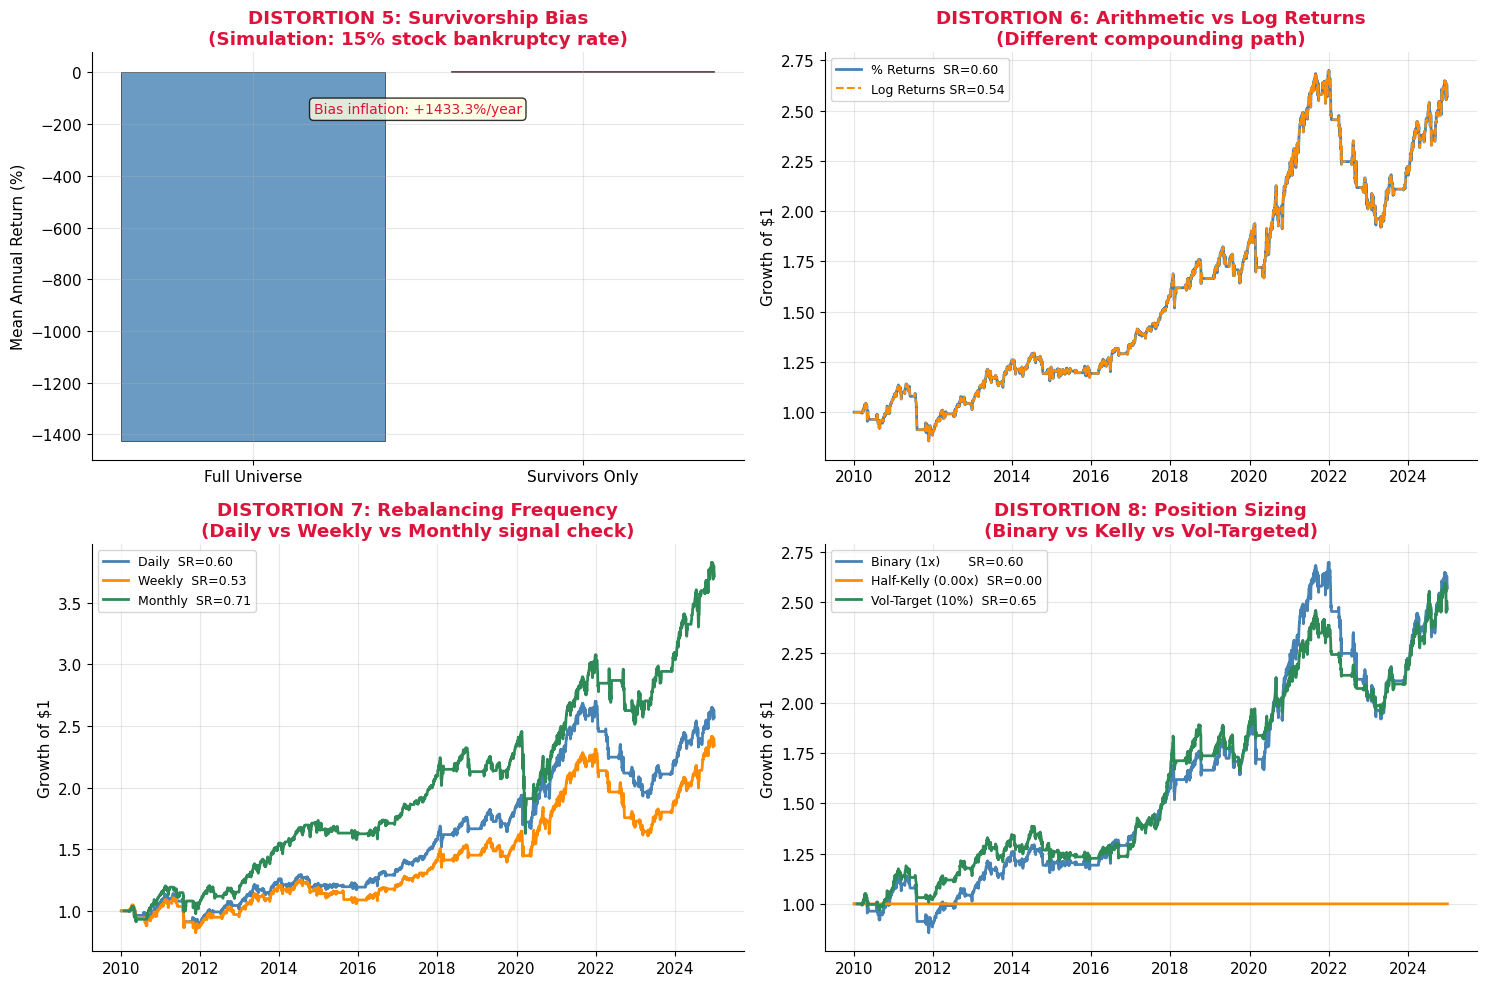


📌 KEY TAKEAWAYS FROM DISTORTION CATALOGUE:
   5. Survivorship bias inflates backtested returns by excluding failures
   6. Log vs arithmetic returns diverge over long horizons
   7. Rebalancing frequency changes your turnover and signal lag
   8. Position sizing can change Sharpe by 0.5+ points for the same signal


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))


# ── DISTORTION 5: Survivorship Bias (conceptual demonstration) ────────────────
# We can't easily recreate this without delisted stocks, but we can show the
# magnitude via simulation
np.random.seed(42)
N_STOCKS   = 500
N_DAYS     = len(returns)
# Simulate 500 stocks: some survive (positive drift), some fail (hit 0)
survivor_returns    = np.random.normal(0.0003, 0.015, (N_DAYS, N_STOCKS))
bankruptcy_shocks   = np.random.exponential(500, N_STOCKS).astype(int)   # day of bankruptcy
bankruptcy_shocks   = np.minimum(bankruptcy_shocks, N_DAYS - 1)
# Mark bankrupt stocks to zero after their bankruptcy day
full_universe_rets  = survivor_returns.copy()
for j, b in enumerate(bankruptcy_shocks):
    if np.random.random() < 0.15:   # 15% of stocks go bankrupt
        full_universe_rets[b:, j] = -1  # complete loss

# Survivorship-biased: only include stocks that survived to end
survived_mask       = full_universe_rets[-1, :] > -0.99
biased_mean_return  = survivor_returns[:, survived_mask].mean(axis=1).mean() * 252
full_mean_return    = full_universe_rets.clip(-0.5, 0.5).mean(axis=1).mean() * 252

ax = axes[0, 0]
ax.bar(['Full Universe', 'Survivors Only'],
       [full_mean_return * 100, biased_mean_return * 100],
       color=['steelblue', 'crimson'], alpha=0.8, edgecolor='black', lw=0.5)
ax.set_title('DISTORTION 5: Survivorship Bias\n(Simulation: 15% stock bankruptcy rate)',
             fontweight='bold', color='crimson')
ax.set_ylabel('Mean Annual Return (%)')
ax.text(0.5, 0.85, f'Bias inflation: +{(biased_mean_return-full_mean_return)*100:.1f}%/year',
        transform=ax.transAxes, ha='center', fontsize=10, color='crimson',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))


# ── DISTORTION 6: Returns vs Log Returns ──────────────────────────────────────
log_returns   = np.log(price / price.shift(1)).dropna()
pct_returns   = price.pct_change().dropna()

sig_base, _, _ = ma_crossover_signal(price, fast=FAST, slow=SLOW)
r_pct = (sig_base * pct_returns).dropna()
r_log = (sig_base.reindex(log_returns.index) * log_returns).dropna()

# Cumulative: arithmetic vs geometric compounding
cum_pct = (1 + r_pct).cumprod()
cum_log = np.exp(r_log.cumsum())     # correct compounding for log returns

ax = axes[0, 1]
ax.plot(cum_pct, color='steelblue',  lw=2,   label=f'% Returns  SR={sharpe(r_pct):.2f}')
ax.plot(cum_log, color='darkorange', lw=1.5, label=f'Log Returns SR={sharpe(r_log):.2f}',
        linestyle='--')
ax.set_title('DISTORTION 6: Arithmetic vs Log Returns\n(Different compounding path)',
             fontweight='bold', color='crimson')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)


# ── DISTORTION 7: Rebalancing Frequency ──────────────────────────────────────
# Does it matter if we check the signal daily vs weekly vs monthly?
rebal_results = {}

sig_daily, _, _ = ma_crossover_signal(price, fast=FAST, slow=SLOW)

for freq, label in [('D', 'Daily'), ('W', 'Weekly'), ('ME', 'Monthly')]:
    if freq == 'D':
        sig_freq = sig_daily
    else:
        # Resample signal: only update on rebalance days, hold otherwise
        sig_resampled = sig_daily.resample(freq).last().reindex(sig_daily.index, method='ffill')
        sig_freq = sig_resampled
    r = (sig_freq * returns).dropna()
    rebal_results[label] = r

ax = axes[1, 0]
colors = ['steelblue', 'darkorange', 'seagreen']
for (label, r), color in zip(rebal_results.items(), colors):
    ax.plot((1 + r).cumprod(), label=f'{label}  SR={sharpe(r):.2f}',
            color=color, lw=2)
ax.set_title('DISTORTION 7: Rebalancing Frequency\n(Daily vs Weekly vs Monthly signal check)',
             fontweight='bold', color='crimson')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)


# ── DISTORTION 8: Position Sizing ─────────────────────────────────────────────
sig_pos, _, _ = ma_crossover_signal(price, fast=FAST, slow=SLOW)

# Variant A: Binary (1 or 0)
r_binary = (sig_pos * returns).dropna()

# Variant B: Kelly fraction (half-Kelly for safety)
# Kelly = (p - q/b) where p=hit rate, q=miss rate, b=avg_win/avg_loss
r_tmp  = (sig_pos * returns).dropna()
p_win  = (r_tmp > 0).mean()
avg_w  = r_tmp[r_tmp > 0].mean()
avg_l  = abs(r_tmp[r_tmp < 0].mean())
kelly  = (p_win - (1 - p_win) / (avg_w / avg_l)) if avg_l > 0 else 1
half_kelly = max(0, min(kelly / 2, 2))   # half-Kelly, capped at 2x
r_kelly = (sig_pos * returns * half_kelly).dropna()

# Variant C: Vol-targeted (target 10% annual vol)
roll_vol = returns.rolling(20).std() * np.sqrt(252)
scalar   = (0.10 / roll_vol).clip(0, 3)
r_vt     = (sig_pos * scalar.shift(1) * returns).dropna()

ax = axes[1, 1]
for r, label, color in [
    (r_binary, f'Binary (1x)       SR={sharpe(r_binary):.2f}',  'steelblue'),
    (r_kelly,  f'Half-Kelly ({half_kelly:.2f}x)  SR={sharpe(r_kelly):.2f}',  'darkorange'),
    (r_vt,     f'Vol-Target (10%)  SR={sharpe(r_vt):.2f}',  'seagreen'),
]:
    ax.plot((1 + r).cumprod(), label=label, lw=2, color=color)
ax.set_title('DISTORTION 8: Position Sizing\n(Binary vs Kelly vs Vol-Targeted)',
             fontweight='bold', color='crimson')
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n📌 KEY TAKEAWAYS FROM DISTORTION CATALOGUE:')
print('   5. Survivorship bias inflates backtested returns by excluding failures')
print('   6. Log vs arithmetic returns diverge over long horizons')
print('   7. Rebalancing frequency changes your turnover and signal lag')
print('   8. Position sizing can change Sharpe by 0.5+ points for the same signal')

### 6.6 — The Implementation Checklist

Before declaring any backtest result valid, every honest quant should answer these questions:

In [15]:
checklist = {
    '1. Look-ahead bias': {
        'Question': 'Is every signal variable computed only from data available at decision time?',
        'Test':     'Add .shift(1) to all signals. Does performance change? If yes, you had bias.',
        'Our code': '✅ All signals use .shift(1)'
    },
    '2. Transaction costs': {
        'Question': 'Does the strategy survive realistic transaction costs?',
        'Test':     'Apply 5–20 bps per trade. Does Sharpe stay positive?',
        'Our code': '✅ Tested 0–50 bps range'
    },
    '3. Parameter stability': {
        'Question': 'Does performance hold over a wide parameter range, not just the optimised point?',
        'Test':     'Plot Sharpe heatmap. Is the profitable region wide or narrow?',
        'Our code': '✅ 2D heatmaps computed'
    },
    '4. Out-of-sample test': {
        'Question': 'Were parameters chosen using the same data used to evaluate performance?',
        'Test':     'Hold out 30–40% of data. Never look at it during development.',
        'Our code': '✅ 60/40 IS/OOS split tested'
    },
    '5. Survivorship bias': {
        'Question': 'Does your universe include assets that failed or were delisted?',
        'Test':     'Use point-in-time constituent data, not current index members.',
        'Our code': '⚠️  Using single ETF — no survivorship issue for this test'
    },
    '6. Drawdown realism': {
        'Question': 'Could you have held the strategy through its worst drawdown?',
        'Test':     'Look at worst 3-month period. Would investors have redeemed?',
        'Our code': '✅ Max drawdown computed for all strategies'
    },
    '7. Capacity': {
        'Question': 'Would this strategy work at the capital size you intend to run it?',
        'Test':     'Compare trade size to average daily volume. >5% ADV is problematic.',
        'Our code': '⚠️  Not tested — SPY is highly liquid, capacity is unlikely a constraint'
    },
    '8. Multiple testing': {
        'Question': 'How many variants did you try before arriving at this result?',
        'Test':     'Apply Bonferroni or BHY correction. With 100 tests, expect 5 false positives at p<0.05.',
        'Our code': '⚠️  Parameter grid = multiple comparisons. OOS test partially mitigates this.'
    }
}

print('\n✅ STRATEGY IMPLEMENTATION CHECKLIST\n')
print('=' * 78)
for item, details in checklist.items():
    print(f'\n{item}')
    print(f'  Question: {details["Question"]}')
    print(f'  Test:     {details["Test"]}')
    print(f'  Status:   {details["Our code"]}')
print('\n' + '=' * 78)


✅ STRATEGY IMPLEMENTATION CHECKLIST


1. Look-ahead bias
  Question: Is every signal variable computed only from data available at decision time?
  Test:     Add .shift(1) to all signals. Does performance change? If yes, you had bias.
  Status:   ✅ All signals use .shift(1)

2. Transaction costs
  Question: Does the strategy survive realistic transaction costs?
  Test:     Apply 5–20 bps per trade. Does Sharpe stay positive?
  Status:   ✅ Tested 0–50 bps range

3. Parameter stability
  Question: Does performance hold over a wide parameter range, not just the optimised point?
  Test:     Plot Sharpe heatmap. Is the profitable region wide or narrow?
  Status:   ✅ 2D heatmaps computed

4. Out-of-sample test
  Question: Were parameters chosen using the same data used to evaluate performance?
  Test:     Hold out 30–40% of data. Never look at it during development.
  Status:   ✅ 60/40 IS/OOS split tested

5. Survivorship bias
  Question: Does your universe include assets that failed or wer

---
## 🏁 Module 7 — Final Comparison Dashboard


📋 FINAL STRATEGY COMPARISON

                           Ann. Return Ann. Vol Sharpe Max Drawdown Hit Rate
Label                                                                       
Buy & Hold                       14.3%    17.1%   0.84       -33.7%    55.3%
MA Cross 20/50 (no cost)          7.0%    11.6%   0.60       -28.9%    39.0%
MA Cross 20/50 (10bps)            6.5%    11.6%   0.56       -29.6%    38.9%
Mean Rev z=1.5 (no cost)          0.0%    15.4%   0.00       -44.8%    37.6%
Mean Rev z=1.5 (10bps)           -2.1%    15.4%  -0.13       -52.9%    37.2%
Vol Breakout 20d (no cost)        0.0%     0.0%   0.00         0.0%     0.0%
Vol Breakout 20d (10bps)          0.0%     0.0%   0.00         0.0%     0.0%


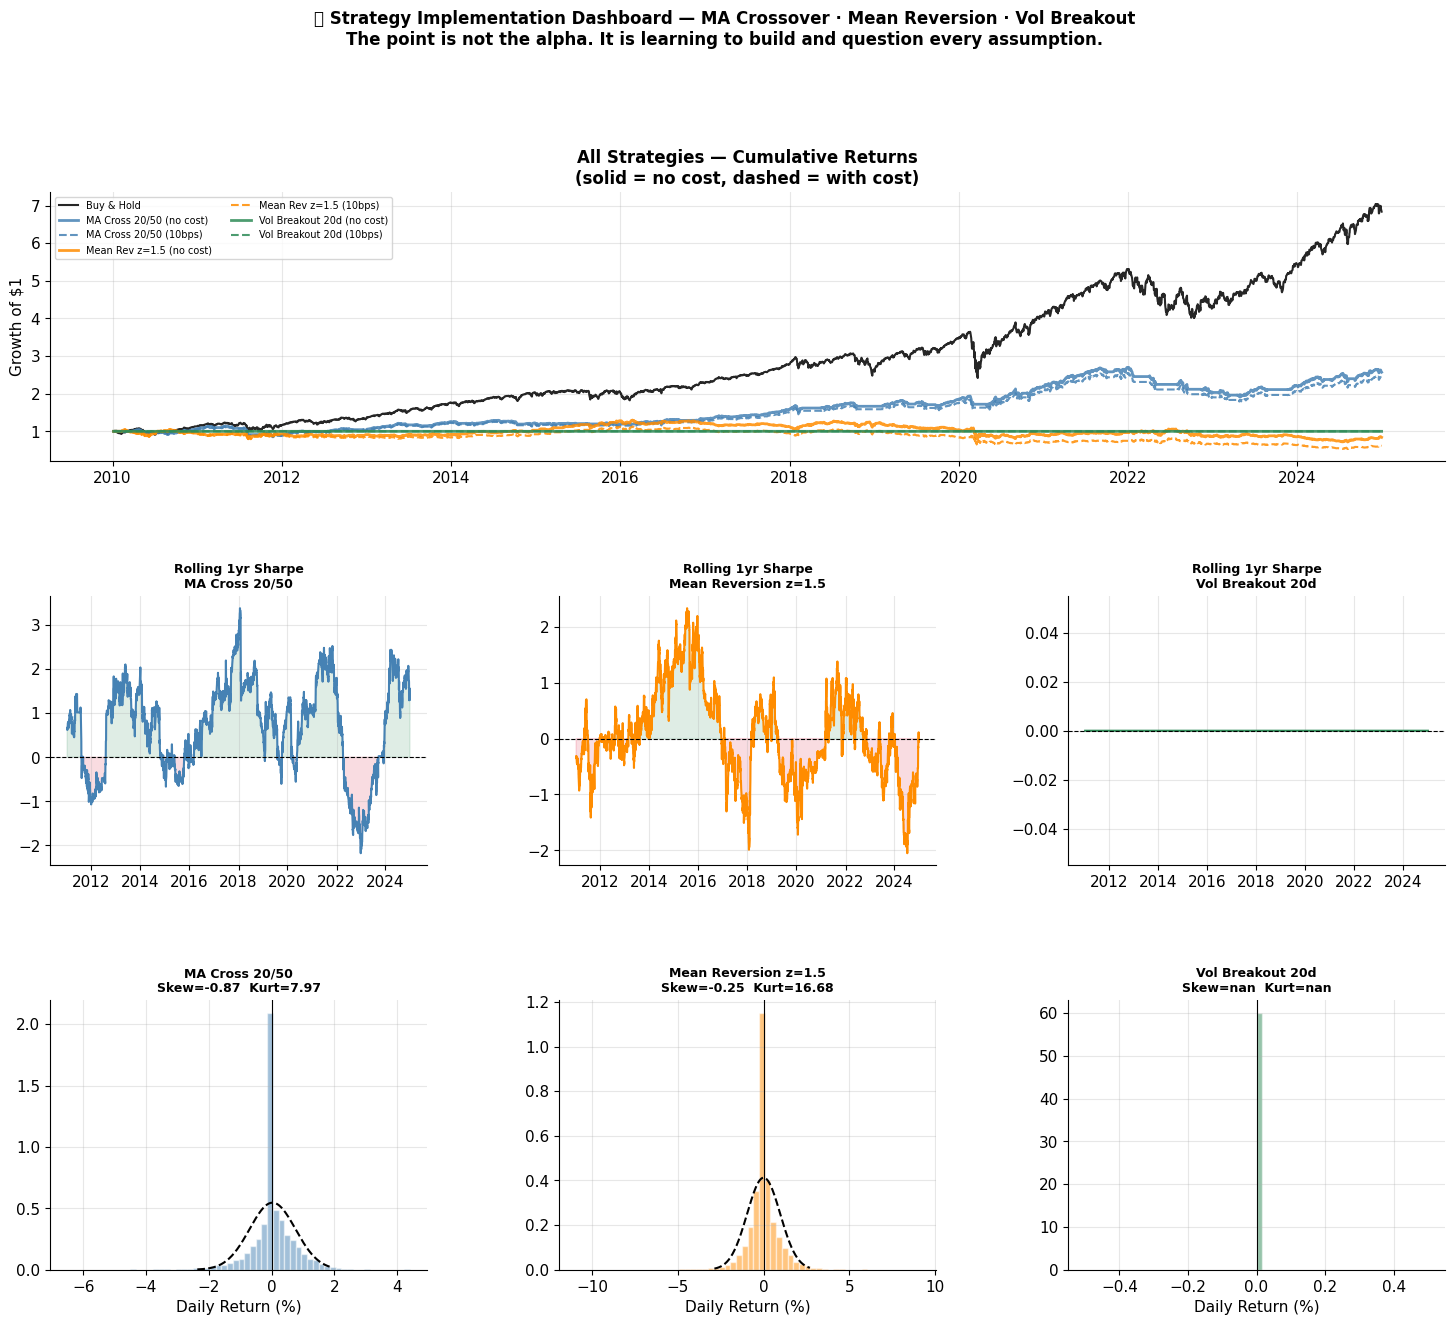

In [16]:
# Collect all strategies with costs applied
COST_BPS = 10  # realistic cost assumption

sig_ma, _, _    = ma_crossover_signal(price, fast=FAST, slow=SLOW)
sig_mr, _       = zscore_signal(price, window=MR_WINDOW, entry_z=ENTRY_Z, exit_z=EXIT_Z)
sig_vb, _, _, _ = volatility_breakout_signal(price, high, low,
                                              channel_window=CH_WINDOW, atr_mult=ATR_MULT)

strategies = {
    'Buy & Hold':            returns,
    f'MA Cross {FAST}/{SLOW} (no cost)': sig_ma * returns,
    f'MA Cross {FAST}/{SLOW} ({COST_BPS}bps)': apply_transaction_costs(sig_ma, returns, COST_BPS),
    f'Mean Rev z={ENTRY_Z} (no cost)':    sig_mr * returns,
    f'Mean Rev z={ENTRY_Z} ({COST_BPS}bps)': apply_transaction_costs(sig_mr, returns, COST_BPS),
    f'Vol Breakout {CH_WINDOW}d (no cost)': sig_vb * returns,
    f'Vol Breakout {CH_WINDOW}d ({COST_BPS}bps)': apply_transaction_costs(sig_vb, returns, COST_BPS),
}

# ── Summary table ─────────────────────────────────────────────────────────────
rows = [summary_stats(r, label) for label, r in strategies.items()]
summary_df = pd.DataFrame(rows).set_index('Label')
print('\n📋 FINAL STRATEGY COMPARISON\n')
print(summary_df.to_string())

# ── Dashboard ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

colors_all = ['black', 'steelblue', 'steelblue',
              'darkorange', 'darkorange', 'seagreen', 'seagreen']
styles_all = ['-', '-', '--', '-', '--', '-', '--']
widths_all = [1.5, 2, 1.5, 2, 1.5, 2, 1.5]

# ── Panel 1: All cumulative returns ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for (label, r), color, style, lw in zip(strategies.items(),
                                         colors_all, styles_all, widths_all):
    ax1.plot((1 + r.dropna()).cumprod(), label=label,
             color=color, linestyle=style, lw=lw, alpha=0.85)
ax1.set_title('All Strategies — Cumulative Returns\n(solid = no cost, dashed = with cost)',
              fontweight='bold', fontsize=12)
ax1.set_ylabel('Growth of $1')
ax1.legend(fontsize=7, ncol=2)

# ── Panels 2–4: Rolling Sharpe for each strategy ─────────────────────────────
strategy_triples = [
    (f'MA Cross {FAST}/{SLOW}', sig_ma * returns, 'steelblue'),
    (f'Mean Reversion z={ENTRY_Z}', sig_mr * returns, 'darkorange'),
    (f'Vol Breakout {CH_WINDOW}d', sig_vb * returns, 'seagreen'),
]
for col, (label, r, color) in enumerate(strategy_triples):
    ax = fig.add_subplot(gs[1, col])
    roll_sr = r.rolling(252).apply(lambda x: sharpe(pd.Series(x)), raw=False)
    ax.plot(roll_sr, color=color, lw=1.5)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.fill_between(roll_sr.index, roll_sr, 0,
                    where=(roll_sr > 0), alpha=0.15, color='seagreen')
    ax.fill_between(roll_sr.index, roll_sr, 0,
                    where=(roll_sr < 0), alpha=0.15, color='crimson')
    ax.set_title(f'Rolling 1yr Sharpe\n{label}', fontweight='bold', fontsize=9)

# ── Panels 5–7: Return distributions ─────────────────────────────────────────
for col, (label, r, color) in enumerate(strategy_triples):
    ax  = fig.add_subplot(gs[2, col])
    r_c = r.dropna() * 100
    ax.hist(r_c, bins=60, density=True, color=color, alpha=0.5,
            edgecolor='white', lw=0.2)
    mu, sig2 = r_c.mean(), r_c.std()
    x = np.linspace(r_c.quantile(0.01), r_c.quantile(0.99), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sig2), 'k--', lw=1.5, label='Normal')
    ax.axvline(0, color='black', lw=0.8)
    sk = stats.skew(r_c)
    ku = stats.kurtosis(r_c)
    ax.set_title(f'{label}\nSkew={sk:.2f}  Kurt={ku:.2f}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Daily Return (%)')

fig.suptitle(
    '🏁 Strategy Implementation Dashboard — MA Crossover · Mean Reversion · Vol Breakout\n'
    'The point is not the alpha. It is learning to build and question every assumption.',
    fontsize=12, fontweight='bold', y=1.01
)
plt.show()

---
## 📚 Summary — What You Built and Learned

### Three Strategies

| Strategy | Hypothesis | Key Parameter | Fails When |
|---|---|---|---|
| MA Crossover | Momentum persists | Fast/slow window ratio | Range-bound, whipsaw markets |
| Mean Reversion | Extremes revert | Entry z-score threshold | Trending markets, structural breaks |
| Vol Breakout | Breakouts signal directional moves | Channel + ATR multiplier | Low-vol, range-bound markets |

---

### Eight Ways Implementation Choices Distort Results

| Distortion | Typical Magnitude | Fix |
|---|---|---|
| Look-ahead bias | +20–100% Sharpe inflation | Always `.shift(1)` |
| No transaction costs | +30–80% Sharpe inflation | Apply 5–20 bps per trade |
| Signal smoothing lag | ±20% Sharpe swing | Test vs raw signal |
| Overfitting | Best IS param = average OOS | Holdout set |
| Survivorship bias | +1–5% annual return inflation | Point-in-time universe |
| Returns vs log returns | Diverges over long horizons | Be consistent |
| Rebalancing frequency | ±15% Sharpe swing | Match to signal frequency |
| Position sizing | ±0.5 Sharpe | Vol-targeting improves stability |

---

## 🚀 Next Steps

1. **Try on different assets** — TSLA, GLD, BTC-USD. Do the same parameters work?
2. **Combine signals** — vote between MA crossover + mean reversion to reduce regime dependence
3. **Walk-forward testing** — retrain parameters every quarter on expanding window
4. **Add regime filter** — only trade mean reversion in low-VIX environments (from the previous notebook)
5. **Portfolio of strategies** — allocate across all three and measure diversification benefit
6. **Factor the signal** — what drives when the strategy works? (Use the Wasserstein regime notebook)

